In [26]:
import pandas as pd
import numpy as np
from datetime import datetime
import re
import sys
import matplotlib.pyplot as plt
from functools import reduce

In [27]:
ticket = "MELI"
ruta = "USA/"
archivo = f'{ticket}.xlsx'
ruta_archivo = ruta + archivo
archivo_stock = f"USA/DatosHistoricos/Datos históricos {ticket}"
archivo_market = "Datos históricos del S&P 500 TR"
market_risk_premium = 0.07
archivo_market_bonos = "bonos_usa"
archivo_inflacion_usa = "inflation_usa"

In [28]:
df_err = pd.read_excel(ruta_archivo, header=19)
# Filas a eliminar (ajustar índices para que sean 0-based)
filas_a_eliminar = [1, 17, 55, 88, 153, 194, 218,256]
# Eliminar las filas
df_err = df_err.drop(filas_a_eliminar)
df_err.columns = df_err.iloc[0]
if '\t' in df_err.columns:
    df = df_err.drop(columns=['\t'])
df_err = df_err[1:].reset_index(drop=True)

In [29]:
cols = df_err.columns.tolist()
ttm_idx = cols.index("TTM/current")
df_hist = df_err.iloc[:, :ttm_idx].copy() 

valid_headers = []

row = df_hist.loc[df_hist["Fiscal Period"].eq("Revenue per Share")].iloc[0]

valid_headers = [
    col for col in df_hist.columns
    if col != "Fiscal Period"
    and not pd.isna(row[col])
    and not (isinstance(row[col], str) and row[col].strip() == "-")
]

valid_years = [int(h[-4:]) for h in valid_headers]

last_20_years = valid_years[-20:]

last_20_years

[2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024]

In [30]:
def calcular_crecimiento_syp(archivo_csv, anio_cierre, periodo_anos=5):
    df = pd.read_csv(f"{archivo_csv}.csv")
    df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d.%m.%Y')
    df['Cierre'] = df['Cierre'].str.replace(',', '').astype(float)
    df = df.sort_values('Fecha')
    
    # Filtrar datos del año de cierre
    df_ano = df[df['Fecha'].dt.year == anio_cierre]
    if df_ano.empty:
        raise ValueError(f"No hay datos para el año {anio_cierre}")
    fecha_final = df_ano['Fecha'].max()
    fecha_inicio = fecha_final - pd.DateOffset(years=periodo_anos)
    
    df_filtrado = df[(df['Fecha'] >= fecha_inicio) & (df['Fecha'] <= fecha_final)]
    if df_filtrado.shape[0] < 2:
        raise ValueError("Datos insuficientes para el período solicitado")
    
    precio_inicial = df_filtrado.iloc[0]['Cierre']
    precio_final = df_filtrado.iloc[-1]['Cierre']
    
    tasa = ((precio_final / precio_inicial) ** (1 / periodo_anos)) - 1
    return fecha_inicio.date(), fecha_final.date(), tasa 


crecimiento_syp_porcentaje_años = []

for año in last_20_years:
    fi, ff, tasa = calcular_crecimiento_syp(archivo_market, año)
    crecimiento_syp_porcentaje_años.append({
        "año_cierre": año,
        "fecha_inicio": fi,
        "fecha_final": ff,
        "CAGR_%": round(tasa, 4)
    })



In [31]:

data_bonos = pd.read_csv(archivo_market_bonos + '.csv' , header=0)

data_bonos['observation_date'] = pd.to_datetime(data_bonos['observation_date'], format='%Y-%m-%d')
data_bonos = data_bonos.rename(columns={data_bonos.columns[1]: 'DGS1'})

data_bonos = data_bonos[data_bonos['observation_date'].dt.year.isin(last_20_years)]

promedio_bonos = (
    data_bonos
    .groupby(data_bonos['observation_date'].dt.year)['DGS1']
    .mean()
    .reset_index()
    .rename(columns={'observation_date': 'Año', 'DGS1': 'Promedio_Anual'})
)
promedio_bonos['Promedio_Anual'] = promedio_bonos['Promedio_Anual'].round(4)
print(promedio_bonos)

     Año  Promedio_Anual
0   2005          3.6244
1   2006          4.9346
2   2007          4.5302
3   2008          1.8463
4   2009          0.4715
5   2010          0.3192
6   2011          0.1810
7   2012          0.1746
8   2013          0.1321
9   2014          0.1202
10  2015          0.3179
11  2016          0.6166
12  2017          1.2038
13  2018          2.3306
14  2019          2.0575
15  2020          0.3900
16  2021          0.1051
17  2022          2.8079
18  2023          5.0835
19  2024          4.6919


In [32]:


data_inflacion_usa = pd.read_csv(archivo_inflacion_usa + ".csv")

data_inflacion_usa["observation_date"] = pd.to_datetime(
    data_inflacion_usa["observation_date"],
    dayfirst=True,
    errors="coerce"
)

data_inflacion_usa["CPIAUCSL_PC1"] = pd.to_numeric(
    data_inflacion_usa["CPIAUCSL_PC1"],
    errors="coerce"
)

data_inflacion_usa = data_inflacion_usa[
    data_inflacion_usa["observation_date"].dt.year.isin(last_20_years)
]

df_resultados_inf_usa = (
    data_inflacion_usa
    .assign(Año=data_inflacion_usa["observation_date"].dt.year)
    .groupby("Año", as_index=False)["CPIAUCSL_PC1"]
    .mean()
    .rename(columns={"CPIAUCSL_PC1": "Tasa de Inflación"})
    .sort_values("Año")
    .reset_index(drop=True)
)

df_resultados_inf_usa["Tasa de Inflación"] = (
    df_resultados_inf_usa["Tasa de Inflación"] / 100
).round(4)

print(df_resultados_inf_usa)


     Año  Tasa de Inflación
0   2005             0.0336
1   2006             0.0323
2   2007             0.0287
3   2008             0.0383
4   2009            -0.0031
5   2010             0.0164
6   2011             0.0314
7   2012             0.0208
8   2013             0.0147
9   2014             0.0162
10  2015             0.0012
11  2016             0.0127
12  2017             0.0213
13  2018             0.0244
14  2019             0.0181
15  2020             0.0125
16  2021             0.0467
17  2022             0.0800
18  2023             0.0415
19  2024             0.0295


In [33]:

df_stock  = pd.read_csv(f"{archivo_stock}.csv")
df_market = pd.read_csv(f"{archivo_market}.csv")


df_stock['Fecha'] = pd.to_datetime(df_stock['Fecha'], format='%Y-%m-%d', errors='coerce')
df_stock = df_stock.dropna(subset=['Fecha']).sort_values('Fecha').copy()

df_stock['Cierre'] = (
    df_stock['Cierre']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df_stock['Cierre'] = pd.to_numeric(df_stock['Cierre'], errors='coerce')
df_stock = df_stock.dropna(subset=['Cierre']).copy()

df_stock['Rend_Stock'] = df_stock['Cierre'].pct_change()
df_stock = df_stock.dropna(subset=['Rend_Stock']).copy()


df_market['Fecha'] = pd.to_datetime(df_market['Fecha'], format='%d.%m.%Y', errors='coerce')
df_market = df_market.dropna(subset=['Fecha']).sort_values('Fecha').copy()

df_market['Cierre'] = (
    df_market['Cierre']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df_market['Cierre'] = pd.to_numeric(df_market['Cierre'], errors='coerce')
df_market = df_market.dropna(subset=['Cierre']).copy()

df_market['Rend_Market'] = df_market['Cierre'].pct_change()
df_market = df_market.dropna(subset=['Rend_Market']).copy()


In [34]:
# Asegurar datetime
df_stock['Fecha'] = pd.to_datetime(df_stock['Fecha'])
df_market['Fecha'] = pd.to_datetime(df_market['Fecha'])

# Nos quedamos solo con lo que necesitamos
df_stock_beta = df_stock[['Fecha', 'Rend_Stock']].copy()
df_market_beta = df_market[['Fecha', 'Rend_Market']].copy()

df_beta = pd.merge_asof(
    df_stock_beta.sort_values('Fecha'),
    df_market_beta.sort_values('Fecha'),
    on='Fecha',
    direction='nearest'
)

df_beta['Año'] = df_beta['Fecha'].dt.year

def beta_anual(grupo):
    if len(grupo) < 10:   
        return np.nan
    cov = grupo['Rend_Stock'].cov(grupo['Rend_Market'])
    var_m = grupo['Rend_Market'].var()
    return cov / var_m if var_m != 0 else np.nan

df_beta_resultado = (
    df_beta 
    .groupby('Año')
    .apply(beta_anual)
    .reset_index(name='Beta')
)

df_beta_resultado = df_beta_resultado.dropna(subset=['Beta'])

C:\Users\mar_c\AppData\Local\Temp\ipykernel_21192\2780385894.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(beta_anual)


In [173]:
df_beta_resultado

,Año,Beta
0,2007,2.352146
1,2008,1.611444
2,2009,1.394581
3,2010,1.386554
4,2011,1.480934
5,2012,1.543861
6,2013,2.055946
7,2014,1.420444
8,2015,1.358694
9,2016,1.737004


In [35]:
df_beta_20y = df_beta_resultado[df_beta_resultado['Año'].isin(last_20_years)].copy()
df_beta_20y

,Año,Beta
0,2007,2.352146
1,2008,1.611444
2,2009,1.394581
3,2010,1.386554
4,2011,1.480934
5,2012,1.543861
6,2013,2.055946
7,2014,1.420444
8,2015,1.358694
9,2016,1.737004


In [36]:
# Obtengo los DF para datos anulaes y trimestrales
indice_ttm = df_err.columns.get_loc('TTM/current')

df_anual = df_err.iloc[:, :indice_ttm + 1]
df_trimestral = df_err.iloc[:, indice_ttm + 1:]
df_trimestral.insert(0, 'Fiscal Period', df_err['Fiscal Period'])


In [37]:
columna_anterior = df_anual.columns[indice_ttm - 1]
anio_anterior = int(columna_anterior[-4:])
# Identificar las columnas que contienen un año en su nombre
pattern = re.compile(r'\d{4}')
columnas_con_anio = [col for col in df_anual.columns if pattern.search(col)]

anio_limite = min(last_20_years)

columnas_filtradas = [col for col in columnas_con_anio if int(
    pattern.search(col).group()) >= anio_limite]

# Asegurarse de incluir 'Fiscal Period' y 'TTM/current' si están presentes
columnas_especiales = ['Fiscal Period', 'TTM/current']
columnas_filtradas = [
    col for col in df_anual.columns if col in columnas_especiales] + columnas_filtradas

df_anual_filtrado = df_anual[columnas_filtradas]

# Mover la columna 'TTM/current' al final
if 'TTM/current' in df_anual_filtrado.columns:
    columnas_ordenadas = [
        col for col in df_anual_filtrado.columns if col != 'TTM/current'] + ['TTM/current']
    df_anual_filtrado = df_anual_filtrado[columnas_ordenadas]

df_anual_filtrado = df_anual_filtrado.fillna(0)


In [38]:
df_anual_filtrado

,Fiscal Period,Dec2005,Dec2006,Dec2007,Dec2008,Dec2009,Dec2010,Dec2011,Dec2012,Dec2013,...,Dec2016,Dec2017,Dec2018,Dec2019,Dec2020,Dec2021,Dec2022,Dec2023,Dec2024,TTM/current
0,Revenue per Share,2.066,3.959,3.341,3.09,3.915,4.909,6.771,8.462,10.704,...,19.123,27.55,32.33,47.159,79.895,141.939,209.989,296.175,409.827,516.658
1,EBITDA per Share,0.174,0.564,0.764,0.93,1.358,1.912,2.704,3.405,4.017,...,5.434,2.751,0.822,0.656,5.891,13.533,25.674,44.131,63.396,73.2
2,EBIT per Share,0.059,0.411,0.673,0.854,1.27,1.8,2.539,3.202,3.748,...,4.777,1.824,-0.207,-0.85,3.78,9.437,17.824,33.858,51.226,58.76
3,Earnings per Share (Diluted),0.05,0.01,0.22,0.42,0.75,1.27,1.73,2.3,2.66,...,3.09,0.31,-0.82,-3.71,-0.08,1.67,9.53,19.46,37.69,40.98
4,EPS without NRI,0.042,0.095,0.381,0.441,0.797,1.271,1.692,2.3,2.639,...,3.411,1.958,-1.09,-3.687,0.491,3.114,11.914,27.104,40.512,45.583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,Profitability Rank,0,0,4,5,7,8,8,9,9,...,10,10,10,9,9,8,8,7,8,8
252,GF Value Rank,0,0,0,0,0,5,6,4,4,...,8,10,6,6,3,2,4,6,9,4
253,Growth Rank,0,0,0,5,5,7,8,8,9,...,10,10,10,8,7,6,10,10,10,10
254,Momentum Rank,0,0,0,0,6,8,5,7,10,...,9,8,9,0,6,7,9,6,8,7


In [39]:
pattern = re.compile(r"\d{4}")

columnas_con_anio_trimestral = [
    col for col in df_trimestral.columns
    if col != "Fiscal Period" and pattern.search(str(col))
]

anio_min = min(last_20_years)
anio_max = max(last_20_years)

columnas_filtradas_trimestral = [
    col for col in columnas_con_anio_trimestral
    if anio_min <= int(pattern.search(str(col)).group()) <= anio_max
]

# (Opcional) ordenar por año para que queden en secuencia
columnas_filtradas_trimestral.sort(key=lambda c: int(pattern.search(str(c)).group()))

columnas_especiales_trimestral = ["Fiscal Period"]

df_trimestral_filtrado = df_trimestral[columnas_especiales_trimestral + columnas_filtradas_trimestral].copy()
df_trimestral_filtrado = df_trimestral_filtrado.fillna(0)

In [40]:
df_anual_filtrado = df_anual_filtrado.drop(columns=["TTM/current"])

In [41]:
def limpiar_df_financiero(df):
    df = df.copy()

    # Reemplazar '-' por NaN en todo el DF
    df.replace('-', np.nan, inplace=True)

    # Todas las columnas excepto 'Fiscal Period' a numéricas
    cols_datos = df.columns.drop('Fiscal Period')

    df[cols_datos] = df[cols_datos].apply(
        pd.to_numeric, errors='coerce'
    )

    return df

df_anual_filtrado = limpiar_df_financiero(df_anual_filtrado)
df_trimestral_filtrado = limpiar_df_financiero(df_trimestral_filtrado)

In [42]:
df_anual_filtrado = df_anual_filtrado.dropna(axis=1, how='all')
df_trimestral_filtrado = df_trimestral_filtrado.dropna(axis=1, how='all')

In [43]:
# Crear DataFrame vacío con las columnas anuales
razones_financieras = pd.DataFrame(
    columns=df_anual_filtrado.columns.difference(['Fiscal Period']))


def agregar_razon_financiera(df_anual_filtrado, fila_numerador, nombre_nueva_fila, *filas_denominadoras, como_porcentaje=True):

    global razones_financieras

    # Obtener la fila numerador
    fila_num = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila_numerador].iloc[0, 1:]

    # Obtener y sumar las filas denominadoras
    fila_den = sum(df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila].iloc[0, 1:].values for fila in filas_denominadoras)

    # Calcular la razón financiera, manejando la división por cero
    razon_financiera = []
    for num, den in zip(fila_num.values, fila_den):
        if den != 0:
            razon = num / den
            if como_porcentaje:
                razon *= 100
            razon_financiera.append(f"{razon:.2f}")
        else:
            razon_financiera.append("no deuda")

    # Agregar el resultado al DataFrame
    razones_financieras.loc[nombre_nueva_fila] = razon_financiera

def agregar_razon_financiera_numerador(df_anual_filtrado, nombre_nueva_fila, fila_denominador, fila_numerador_1, fila_numerador_2, como_porcentaje=True):

    global razones_financieras

    # Obtener las filas numeradoras
    fila_num_1 = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila_numerador_1].iloc[0, 1:]
    fila_num_2 = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila_numerador_2].iloc[0, 1:]

    # Obtener la fila denominador
    fila_den = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila_denominador].iloc[0, 1:]

    # Restar las filas numeradoras
    resta_numeradores = fila_num_1.values - fila_num_2.values

    # Calcular la razón financiera, manejando la división por cero
    razon_financiera = []
    for num, den in zip(resta_numeradores, fila_den.values):
        if den != 0:
            razon = num / den
            if como_porcentaje:
                razon *= 100
            razon_financiera.append(f"{razon:.2f}")
        else:
            razon_financiera.append("no deuda")

    # Agregar el resultado al DataFrame razones_financieras
    razones_financieras.loc[nombre_nueva_fila] = razon_financiera

def agregar_fila(df_anual_filtrado, fila_nombre, nombre_nueva_fila):

    global razones_financieras

    # Obtener la fila relevante
    fila = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila_nombre].iloc[0, 1:]

    # Agregar el resultado al DataFrame
    razones_financieras.loc[nombre_nueva_fila] = fila.values

def agregar_crecimiento_anual(fila_nombre, nombre_nueva_fila):

    global razones_financieras

    # Obtener la fila relevante
    fila = razones_financieras.loc[fila_nombre].astype(float)

    # Calcular el crecimiento año a año (YoY)
    crecimiento_anual = fila.pct_change() * 100

    # Reemplazar NaN por 0
    crecimiento_anual = crecimiento_anual.fillna(0)

    # Formatear el resultado a dos decimales
    crecimiento_anual_formateado = [f"{x:.2f}" for x in crecimiento_anual]

    # Agregar el resultado al DataFrame
    razones_financieras.loc[nombre_nueva_fila] = crecimiento_anual_formateado

def dividir_filas_razones_financieras(fila_numerador, fila_denominador, nombre_nueva_fila, como_porcentaje=True):
    global razones_financieras

    # Obtener las filas relevantes para el cálculo
    fila_num = razones_financieras.loc[fila_numerador].astype(float)
    fila_den = razones_financieras.loc[fila_denominador].astype(float)

    # Calcular la razón financiera
    razon_financiera = fila_num.values / fila_den.values

    # Convertir a porcentaje si es necesario
    if como_porcentaje:
        razon_financiera *= 100

    razon_financiera = pd.Series(razon_financiera).fillna(0).values

    razon_financiera_formateada = [f"{x:.2f}" for x in razon_financiera]

    # Agregar el resultado al DataFrame
    razones_financieras.loc[nombre_nueva_fila] = razon_financiera_formateada



In [44]:
# Llamadas a la función con el nuevo orden de parámetros
agregar_razon_financiera(df_anual_filtrado, 'Depreciation, Depletion and Amortization', 'Amortizacion(%)', 'Gross Profit', como_porcentaje=True)
agregar_razon_financiera(df_anual_filtrado, 'Net Income', 'Beneficio Neto(%)', 'Revenue', como_porcentaje=True)
agregar_fila(df_anual_filtrado, 'Net Income', 'Beneficio Neto')
agregar_razon_financiera(df_anual_filtrado, 'Gross Profit', 'Margen Bruto(%)', 'Revenue', como_porcentaje=True)
agregar_razon_financiera(df_anual_filtrado, 'Operating Income', 'Margen Operativo(%)', 'Revenue', como_porcentaje=True)
agregar_razon_financiera(df_anual_filtrado, 'Net Income', 'EPS', 'Shares Outstanding (Diluted Average)', como_porcentaje=False)
agregar_razon_financiera(df_anual_filtrado, 'Revenue', 'Revenue Per Share', 'Shares Outstanding (Diluted Average)', como_porcentaje=False)
agregar_fila(df_anual_filtrado, 'Shares Outstanding (Diluted Average)', '# de Acciones')
agregar_fila(df_anual_filtrado, 'Revenue', 'Ventas')
agregar_crecimiento_anual('Beneficio Neto', 'Crecimiento Beneficio Neto')
agregar_crecimiento_anual('Ventas', 'Crecimiento Ventas')
agregar_fila(df_anual_filtrado, 'Cost of Goods Sold', 'Costo de Ventas')
agregar_crecimiento_anual('Costo de Ventas', 'Crecimiento Costo de Ventas')
agregar_fila(df_anual_filtrado, 'Total Inventories', 'Inventarios')
agregar_crecimiento_anual('Inventarios', 'Crecimiento Inventarios')
agregar_razon_financiera(df_anual_filtrado, '  Accounts Receivable', 'Cuentas por cobrar/ventas', 'Revenue', como_porcentaje=True)
agregar_fila(df_anual_filtrado, 'Dividends per Share', 'Dividendos por Accion')
agregar_fila(df_anual_filtrado, 'Free Cash Flow', 'Flujo de Caja Libre')
dividir_filas_razones_financieras('Flujo de Caja Libre', 'Ventas', 'FCF/ventas',True)
dividir_filas_razones_financieras('Flujo de Caja Libre','# de Acciones','Free cash flow per share',False)
agregar_razon_financiera(df_anual_filtrado,'Free Cash Flow','FCF/DEBT','Short-Term Debt & Capital Lease Obligation','Long-Term Debt & Capital Lease Obligation',como_porcentaje=False)
agregar_razon_financiera(df_anual_filtrado,'Free Cash Flow','FCF/DEBT corto plazo','Short-Term Debt & Capital Lease Obligation',como_porcentaje=False)
dividir_filas_razones_financieras('Dividendos por Accion',"EPS",'Dividend Payout Ratio',True)
agregar_razon_financiera(df_anual_filtrado,'Net Income','Net Income vs Deuda Largo Plazo','Long-Term Debt & Capital Lease Obligation',como_porcentaje=False)
agregar_razon_financiera(df_anual_filtrado,'Total Liabilities','Pasivo/Fondos Propios','Total Equity',como_porcentaje=False)
agregar_razon_financiera(df_anual_filtrado,'Total Current Assets','Ratio de Solvencia','Total Current Liabilities',como_porcentaje=False)
agregar_razon_financiera(df_anual_filtrado,'Long-Term Debt & Capital Lease Obligation','Deuda/Capital','Total Equity',como_porcentaje=True)
agregar_razon_financiera(df_anual_filtrado,'  Interest Expense','Gasto financiero','Operating Income',como_porcentaje=True) ##Interes Expense viene negativo, tenerlo en cuenta ya que si queda positivo seria malo ya que el operating income es tambien negativo
agregar_razon_financiera(df_anual_filtrado,'Total Inventories','Inventory to current Assetis','Total Current Assets',como_porcentaje=True)
agregar_fila(df_anual_filtrado,'Cash Conversion Cycle','Net Trading Cycle')
agregar_fila(df_anual_filtrado,'PEG Ratio','PEGY Ratio')
agregar_fila(df_anual_filtrado,'PE Ratio','PER')
agregar_fila(df_anual_filtrado,'PS Ratio','P/S Ratio')
agregar_razon_financiera(df_anual_filtrado,'  Accounts Receivable','Receivable to Current Assets','Total Current Assets',como_porcentaje=True)
agregar_fila(df_anual_filtrado,'ROA %','ROA%')
agregar_fila(df_anual_filtrado,'ROE %','ROE%')
agregar_razon_financiera(df_anual_filtrado,'Total Assets','ROB','Total Equity',como_porcentaje=False)
agregar_fila(df_anual_filtrado,'ROIC %','ROIC %')
agregar_fila(df_anual_filtrado,'WACC %','WACC %')
agregar_razon_financiera_numerador(df_anual_filtrado,'Test de Acidez','Total Current Liabilities','Total Current Assets','Total Inventories',como_porcentaje=False)
agregar_fila(df_anual_filtrado,'Book Value per Share','Valor en libros')
agregar_fila(df_anual_filtrado,'Piotroski F-Score','Piotrivski F-Score')
agregar_fila(df_anual_filtrado,'Altman Z-Score','Altman Z score')
agregar_fila(df_anual_filtrado,'Beneish M-Score','Beneish M-Score')
agregar_fila(df_anual_filtrado,'Dividends per Share','Dividendo por accion')
agregar_crecimiento_anual('Dividendo por accion','Crecimiento Dividendo por accion')
razones_financieras

,Dec2005,Dec2006,Dec2007,Dec2008,Dec2009,Dec2010,Dec2011,Dec2012,Dec2013,Dec2014,Dec2015,Dec2016,Dec2017,Dec2018,Dec2019,Dec2020,Dec2021,Dec2022,Dec2023,Dec2024
Amortizacion(%),7.11,5.05,3.45,3.05,2.84,2.89,3.20,3.25,3.47,4.26,5.31,5.41,5.69,6.57,6.65,6.14,6.79,7.75,6.90,6.44
Beneficio Neto(%),8.33,2.06,11.39,13.73,19.21,25.85,25.68,27.10,24.86,13.04,16.23,16.15,1.13,-2.54,-7.49,-0.03,1.17,4.47,6.53,9.20
Beneficio Neto,2.354,1.072,9.693,18.812,33.209,56.025,76.78,101.247,117.507,72.581,105.789,136.366,13.78,-36.585,-171.999,-1.0,83.0,482.0,987.0,1911.0
Margen Bruto(%),78.27,76.78,78.53,79.90,79.20,78.52,75.90,73.75,72.48,71.43,67.01,63.58,59.15,48.42,48.00,43.00,42.51,48.22,50.24,46.09
Margen Operativo(%),2.87,10.37,25.45,27.39,32.42,34.42,33.38,34.70,32.49,30.54,23.85,23.07,11.91,-4.83,-6.67,3.22,6.24,9.92,14.61,12.66
EPS,0.17,0.08,0.38,0.42,0.75,1.27,1.74,2.29,2.66,1.64,2.40,3.09,0.31,-0.82,-3.53,-0.02,1.67,9.39,19.35,37.69
Revenue Per Share,2.07,3.96,3.34,3.09,3.92,4.91,6.77,8.46,10.70,12.60,14.76,19.12,27.55,32.33,47.16,79.90,141.94,209.99,296.18,409.83
# de Acciones,13.671,13.149,25.478,44.349,44.144,44.147,44.151,44.148,44.153,44.154,44.156,44.157,44.157,44.53,48.693,49.74,49.803,51.336,51.007,50.697
Ventas,28.25,52.059,85.126,137.023,172.844,216.716,298.932,373.601,472.595,556.536,651.79,844.396,1216.542,1439.653,2296.314,3974.0,7069.0,10780.0,15107.0,20777.0
Crecimiento Beneficio Neto,0.00,-54.46,804.20,94.08,76.53,68.70,37.05,31.87,16.06,-38.23,45.75,28.90,-89.89,-365.49,370.14,-99.42,-8400.00,480.72,104.77,93.62


In [45]:
dividir_filas_razones_financieras("Costo de Ventas","Inventarios","Rotacion de Inventarios",False)

C:\Users\mar_c\AppData\Local\Temp\ipykernel_21192\3197065731.py:95: RuntimeWarning: divide by zero encountered in divide
  razon_financiera = fila_num.values / fila_den.values


In [46]:
razones_financieras.loc["Beneish M-Score"] = razones_financieras.loc["Beneish M-Score"].astype(float).abs()
razones_financieras.loc["Gasto financiero"] = razones_financieras.loc["Gasto financiero"].astype(float).abs()

In [47]:
razones_financieras = razones_financieras.apply(pd.to_numeric, errors='coerce')

In [174]:
print(type(razones_financieras))

<class 'pandas.core.frame.DataFrame'>


In [48]:
razones_financieras.to_excel(f'Valuaciones_USA/razones_financieras_{ticket}.xlsx', index=True)

In [49]:
# # Convertir los valores a numéricos, convirtiendo los no numéricos a NaN
# razones_financieras_numeric = razones_financieras.apply(pd.to_numeric, errors='coerce')

# # Ignorar las columnas que contienen "2020" o "2021" para las filas específicas
# filas_a_ignorar = ["Crecimiento Beneficio Neto", "Crecimiento Costo de Ventas", "Crecimiento Inventarios", "Crecimiento Ventas", "Crecimiento Dividendo por accion"]

# # Crear una copia del DataFrame para modificar
# razones_financieras_modificado = razones_financieras_numeric.copy()

# # Establecer los valores de las columnas a ignorar en NaN para las filas específicas
# for fila in filas_a_ignorar:
#     for col in razones_financieras_modificado.columns:
#         if '2020' in col or '2021' in col:
#             razones_financieras_modificado.loc[fila, col] = np.nan

# # Calcular el promedio de cada fila, ignorando los NaN y valores no finitos
# promedios = razones_financieras_modificado.apply(lambda row: np.nanmean(row[np.isfinite(row)]), axis=1)

# # Redondear los valores a dos decimales
# promedios_redondeados = promedios.round(2)

# # Convertir los promedios a un DataFrame
# promedios_df = promedios_redondeados.to_frame(name='Promedio')
# promedios_df

## Book Value per Share

In [50]:
total_assets = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Assets'].iloc[0, 1:]
total_liabilities = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Liabilities'].iloc[0, 1:]
total_shares = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Shares Outstanding (Basic Average)'].iloc[0, 1:]

In [51]:
book_value = total_assets - total_liabilities

book_value_per_share = book_value / total_shares

book_value_per_share_anual = pd.DataFrame({
    'Book Value': book_value,
    'Book Value per Share': book_value_per_share
}, index=total_assets.index)

book_value_per_share_anual

,Book Value,Book Value per Share
0,,
Dec2005,-42.407,-3.245848
Dec2006,-40.728,-3.097422
Dec2007,91.673,3.645195
Dec2008,93.424,2.111802
Dec2009,114.194,2.590197
Dec2010,171.718,3.891714
Dec2011,219.179,4.965766
Dec2012,289.813,6.564578
Dec2013,343.484,7.779403


## Liquidation Value


Utilizable con empresas a la baja, si el precio se encuentra por debajo de este,podria ser una oportunidad

1️⃣ Ratio de Recuperación del Efectivo (
𝑅
𝐸
R 
E
​
 )
(Normalmente 100%)
Se incluyen todas las cuentas que representan efectivo o equivalentes de efectivo, que son altamente líquidos.

Cuentas relevantes:

Cash And Cash Equivalents
Marketable Securities
Cash, Cash Equivalents, Marketable Securities (si está consolidado)
2️⃣ Ratio de Recuperación de Cuentas por Cobrar (
𝑅
𝐶
R 
C
​
 )
(Usualmente entre 70-90%)
Se incluyen todas las cuentas por cobrar, notas por cobrar y otros montos adeudados a la empresa.

Cuentas relevantes:

Accounts Receivable
Notes Receivable
Loans Receivable
Other Current Receivables
Total Receivables (si está consolidado)
3️⃣ Ratio de Recuperación de Inventarios (
𝑅
𝐼
R 
I
​
 )
(Suele ser 50-80%)
Incluye todos los bienes en inventario que la empresa posee, como materia prima, productos en proceso y productos terminados.

Cuentas relevantes:

Inventories, Raw Materials & Components
Inventories, Work In Process
Inventories, Finished Goods
Inventories, Other
Total Inventories (si está consolidado)
4️⃣ Ratio de Recuperación de Propiedades, Planta y Equipos (
𝑅
𝑃
R 
P
​
 )
(Usualmente 60-90%)
Incluye activos fijos tangibles como edificios, maquinaria y terrenos.

Cuentas relevantes:

Land And Improvements
Buildings And Improvements
Machinery, Furniture, Equipment
Construction In Progress
Other Gross PPE
Gross Property, Plant and Equipment
Property, Plant and Equipment (si está consolidado)
⚠️ Acumulated Depreciation → Se resta porque representa la pérdida de valor de los activos.
5️⃣ Ratio de Recuperación de Otros Activos Tangibles (
𝑅
𝑂
R 
O
​
 )
(Depende del tipo de activo, entre 10-80%)
Incluye otros activos físicos que no encajan en las categorías anteriores, como infraestructura, vehículos y mobiliario.

Cuentas relevantes:

Investments And Advances (si contiene activos tangibles)
Other Long Term Assets (si son tangibles)
Otros activos que no sean intangibles o Goodwill
⚠️ No se incluyen:

Intangible Assets (valor de marca, patentes, etc.)
Goodwill (ya que en liquidación normalmente no tiene valor)

In [52]:
ratio_recuperacion_efectivo = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Cash, Cash Equivalents, Marketable Securities'].iloc[0, 1:] * 0.95

ratio_recuperacion_cc = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Receivables'].iloc[0, 1:] * 0.75

ratio_recuperacion_inv = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Inventories'].iloc[0, 1:] * 0.60

ratio_recuperacion_ppe = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Property, Plant and Equipment'].iloc[0, 1:] * 0.70

ratio_recuperacion_act_tangibles =df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Investments And Advances'].iloc[0, 1:] + df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Other Long Term Assets'].iloc[0, 1:] *.30

total_liabilities = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Liabilities'].iloc[0, 1:]


In [53]:
liquidation_value = ratio_recuperacion_efectivo + ratio_recuperacion_cc + ratio_recuperacion_inv + ratio_recuperacion_ppe + ratio_recuperacion_act_tangibles - total_liabilities

liquidation_value_per_share = liquidation_value / total_shares

liquidation_value_per_share

0
Dec2005       -5.2108
Dec2006     -5.357328
Dec2007       2.00603
Dec2008      0.087343
Dec2009      0.705303
Dec2010      1.580082
Dec2011      2.322202
Dec2012      3.660624
Dec2013      3.805986
Dec2014      2.992287
Dec2015      1.773622
Dec2016      1.494984
Dec2017     -2.751894
Dec2018     -4.279812
Dec2019      26.14108
Dec2020    -14.360463
Dec2021    -43.793547
Dec2022    -70.637601
Dec2023    -79.821734
Dec2024   -117.769296
dtype: object

## EPV

In [54]:
margen_operativo = razones_financieras.loc["Margen Operativo(%)"].copy()

margen_operativo.index = margen_operativo.index.str.extract(r'(\d{4})').astype(int)[0]

df_margen = margen_operativo.to_frame(name="Margen_Operativo")
df_margen["Margen_Operativo"] = pd.to_numeric(df_margen["Margen_Operativo"], errors="coerce")

df_margen = df_margen.sort_index()
df_margen.index = df_margen.index.astype(int)

# Promedio móvil de 5 años hacia atrás (excluye año actual)
serie_promedios = (
    df_margen["Margen_Operativo"]
        .shift(1)                          
        .rolling(window=5, min_periods=1)
        .mean()
)


df_promedios_ebit = (
    serie_promedios
        .round(2)
        .div(100)                          
        .to_frame(name="Promedio_Margen_Operativo")
        .reset_index()
        .rename(columns={"index": "Año"})
)

df_promedios_ebit

,0,Promedio_Margen_Operativo
0,2005,NaN
1,2006,0.0287
2,2007,0.0662
3,2008,0.1290
4,2009,0.1652
5,2010,0.1970
6,2011,0.2601
7,2012,0.3061
8,2013,0.3246
9,2014,0.3348


In [55]:

ventas = razones_financieras.loc["Ventas"].copy()

ventas.index = ventas.index.str.extract(r'(\d{4})').astype(int)[0]

df_ventas = ventas.to_frame(name="Ventas")
df_ventas["Ventas"] = pd.to_numeric(df_ventas["Ventas"], errors="coerce")

df_ventas = df_ventas.sort_index()
df_ventas.index = df_ventas.index.astype(int)

serie_promedios = (
    df_ventas["Ventas"]
        .shift(1)                          
        .rolling(window=5, min_periods=1)
        .mean()
)


df_promedios_ventas = (
    serie_promedios
        .round(2)
        .to_frame(name="Promedio_Ventas")
        .reset_index()
        .rename(columns={"index": "Año"})
)

df_promedios_ventas


,0,Promedio_Ventas
0,2005,NaN
1,2006,28.25
2,2007,40.15
3,2008,55.14
4,2009,75.61
5,2010,95.06
6,2011,132.75
7,2012,182.13
8,2013,239.82
9,2014,306.94


In [56]:


SGyA = df_trimestral_filtrado[df_trimestral_filtrado['Fiscal Period'] == 'Selling, General, & Admin. Expense'].iloc[0, 1:]
SGyA.index = pd.to_datetime(SGyA.index, format="%b%Y")

df_sgya = SGyA.astype(str).str.replace(",", "").astype(float).to_frame(name="SGyA")
df_sgya["Año"] = df_sgya.index.year

mes_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

headers_df = pd.DataFrame({"Header": valid_headers})
headers_df["Mes"] = headers_df["Header"].str[:3].map(mes_map)
headers_df["Año"] = headers_df["Header"].str[-4:].astype(int)

# fecha base del cierre (primer día del mes del header)
headers_df["Fecha_base"] = pd.to_datetime(
    headers_df["Año"].astype(str) + "-" + headers_df["Mes"].astype(str).str.zfill(2) + "-01"
)

# corte = 1 mes después del mes de cierre fiscal
headers_df["Cutoff"] = headers_df["Fecha_base"] + pd.DateOffset(months=1)

cutoff_por_anio = dict(zip(headers_df["Año"], headers_df["Cutoff"]))

# 3) Años a calcular (sin filtro de 4 trimestres)
anios = sorted(df_sgya["Año"].unique())
ultimos_20_anios = anios[-20:]

# 4) Promedios de los últimos 20 trimestres antes del cutoff fiscal de cada año
promedios_sgya = {}
for año in ultimos_20_anios:
    cutoff = cutoff_por_anio.get(año, pd.to_datetime(f"{año}-01-01"))  # fallback

    datos_previos = df_sgya[df_sgya.index < cutoff].tail(20)
    promedio = round((datos_previos["SGyA"] * 0.75).mean(), 2) if len(datos_previos) else 0
    promedios_sgya[año] = promedio

df_promedios_sgya = (
    pd.DataFrame.from_dict(promedios_sgya, orient="index", columns=["Promedio_SG&A_ajustado"])
    .rename_axis("Año")
    .reset_index()
)

df_promedios_sgya


,Año,Promedio_SG&A_ajustado
0,2005,0.00
1,2006,0.00
2,2007,2.55
3,2008,4.96
4,2009,6.55
5,2010,9.54
6,2011,13.43
7,2012,16.29
8,2013,19.41
9,2014,23.35


In [57]:
# Asegurar que la primera columna se llame "Año"
df_promedios_ventas = df_promedios_ventas.rename(
    columns={df_promedios_ventas.columns[0]: "Año"}
).sort_values("Año").reset_index(drop=True)

df_promedios_ebit = df_promedios_ebit.rename(
    columns={df_promedios_ebit.columns[0]: "Año"}
).sort_values("Año").reset_index(drop=True)

df_promedios_sgya = df_promedios_sgya.rename(
    columns={df_promedios_sgya.columns[0]: "Año"}
).sort_values("Año").reset_index(drop=True)


# Extraer columnas
ventas = df_promedios_ventas["Promedio_Ventas"]
margen = df_promedios_ebit["Promedio_Margen_Operativo"]
sgya = df_promedios_sgya["Promedio_SG&A_ajustado"]

# Calcular EBIT normalizado
ebit_normalizado = round((ventas * margen) + sgya, 2)


df_ebit_normalizado = pd.DataFrame({
    "Año": df_promedios_ventas["Año"],
    "EBIT_normalizado": ebit_normalizado
})

df_ebit_normalizado

,Año,EBIT_normalizado
0,2005,NaN
1,2006,0.81
2,2007,5.21
3,2008,12.07
4,2009,19.04
5,2010,28.27
6,2011,47.96
7,2012,72.04
8,2013,97.26
9,2014,126.11


In [58]:

tax_rate = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Tax Rate %'].iloc[0, 1:]

tax_rate.index = tax_rate.index.str.extract(r'(\d{4})').astype(int)[0]

df_tax = tax_rate.to_frame(name="Tax_Rate")
df_tax["Tax_Rate"] = pd.to_numeric(df_tax["Tax_Rate"], errors="coerce")

promedios_tax = {}
for año in ultimos_20_anios:
    ultimos_5 = df_tax[df_tax.index < año].tail(5)
    positivos = ultimos_5[ultimos_5["Tax_Rate"] >= 0]
    promedio = round(positivos["Tax_Rate"].mean(), 2) / 100
    promedios_tax[año] = promedio

df_promedios_tax = pd.DataFrame.from_dict(promedios_tax, orient='index', columns=['Promedio_Tasa_Impuestos'])
df_promedios_tax.index.name = 'Año'
df_promedios_tax = df_promedios_tax.reset_index().fillna(0)

df_promedios_tax

,Año,Promedio_Tasa_Impuestos
0,2005,0.0000
1,2006,0.0000
2,2007,0.5369
3,2008,0.4324
4,2009,0.4086
5,2010,0.3621
6,2011,0.3337
7,2012,0.2847
8,2013,0.2746
9,2014,0.2583


In [59]:
df_ebit_normalizado = df_ebit_normalizado.sort_values("Año").reset_index(drop=True)
df_promedios_tax = df_promedios_tax.sort_values("Año").reset_index(drop=True)

ebit = df_ebit_normalizado["EBIT_normalizado"]
tax = df_promedios_tax["Promedio_Tasa_Impuestos"]

after_tax_ebit = ebit * (1 - tax)

df_after_tax_ebit = pd.DataFrame({
    "Año": df_ebit_normalizado["Año"],
    "After_Tax_EBIT": after_tax_ebit.round(2)
})

print(df_after_tax_ebit)

     Año  After_Tax_EBIT
0   2005             NaN
1   2006            0.81
2   2007            2.41
3   2008            6.85
4   2009           11.26
5   2010           18.03
6   2011           31.96
7   2012           51.53
8   2013           70.55
9   2014           93.54
10  2015          109.42
11  2016          123.66
12  2017          148.47
13  2018          147.98
14  2019          145.18
15  2020          141.40
16  2021          109.55
17  2022           88.81
18  2023          150.21
19  2024          330.53


In [60]:

DDA = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Depreciation, Depletion and Amortization'].iloc[0, 1:]

DDA.index = DDA.index.str.extract(r'(\d{4})').astype(int)[0]

df_dda = DDA.to_frame(name="DDA")
df_dda["DDA"] = pd.to_numeric(df_dda["DDA"], errors="coerce")


promedios_dda = {}
for año in last_20_years:
    ultimos_5 = df_dda[df_dda.index < año].tail(5)
    promedio = round(ultimos_5["DDA"].mean(), 2)
    promedios_dda[año] = promedio

df_promedios_dda = pd.DataFrame.from_dict(promedios_dda, orient='index', columns=['Promedio_DDA'])
df_promedios_dda.index.name = 'Año'
df_promedios_dda = df_promedios_dda.reset_index()

df_promedios_dda

,Año,Promedio_DDA
0,2005,NaN
1,2006,1.57
2,2007,1.79
3,2008,1.97
4,2009,2.31
5,2010,2.63
6,2011,3.30
7,2012,4.35
8,2013,5.68
9,2014,7.38


In [61]:
df_promedios_dda = df_promedios_dda.sort_values("Año").reset_index(drop=True)
df_promedios_tax = df_promedios_tax.sort_values("Año").reset_index(drop=True)

dda = df_promedios_dda["Promedio_DDA"]
tax = df_promedios_tax["Promedio_Tasa_Impuestos"]

# Calcular Depreciación en exceso
depreciacion_exceso = dda * 0.5 * tax

df_depreciacion_exceso = pd.DataFrame({
    "Año": df_promedios_dda["Año"],
    "Depreciacion_en_exceso": depreciacion_exceso.round(2)
})

print(df_depreciacion_exceso)

     Año  Depreciacion_en_exceso
0   2005                     NaN
1   2006                    0.00
2   2007                    0.48
3   2008                    0.43
4   2009                    0.47
5   2010                    0.48
6   2011                    0.55
7   2012                    0.62
8   2013                    0.78
9   2014                    0.95
10  2015                    1.47
11  2016                    2.11
12  2017                    2.74
13  2018                    4.85
14  2019                    6.71
15  2020                    9.27
16  2021                   18.10
17  2022                   33.03
18  2023                   50.98
19  2024                   77.88


In [62]:
df_after_tax_ebit = df_after_tax_ebit.sort_values("Año").reset_index(drop=True)
df_depreciacion_exceso = df_depreciacion_exceso.sort_values("Año").reset_index(drop=True)

after_tax = df_after_tax_ebit["After_Tax_EBIT"]
dep_exceso = df_depreciacion_exceso["Depreciacion_en_exceso"]

# Calcular earnings normalizados
normalized_earnings = after_tax + dep_exceso

df_normalized_earnings = pd.DataFrame({
    "Año": df_after_tax_ebit["Año"],
    "Normalized_earnings": normalized_earnings.round(2)
})

print(df_normalized_earnings)

     Año  Normalized_earnings
0   2005                  NaN
1   2006                 0.81
2   2007                 2.89
3   2008                 7.28
4   2009                11.73
5   2010                18.51
6   2011                32.51
7   2012                52.15
8   2013                71.33
9   2014                94.49
10  2015               110.89
11  2016               125.77
12  2017               151.21
13  2018               152.83
14  2019               151.89
15  2020               150.67
16  2021               127.65
17  2022               121.84
18  2023               201.19
19  2024               408.41


In [63]:
accumulated_depreciation = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == '  Accumulated Depreciation'].iloc[0, 1:]
gppe = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Gross Property, Plant and Equipment'].iloc[0, 1:]

accumulated_depreciation.index = accumulated_depreciation.index.str.extract(r'(\d{4})').astype(int)[0]
gppe.index = gppe.index.str.extract(r'(\d{4})').astype(int)[0]

accumulated_depreciation = pd.to_numeric(accumulated_depreciation, errors='coerce').abs()
gppe = pd.to_numeric(gppe, errors='coerce')

# Unir en DataFrame
df_ppe = pd.DataFrame({
    "Gross_PPE": gppe,
    "Accumulated_Depreciation": accumulated_depreciation
})

# Calcular Net PPE
df_ppe["Net_PPE"] = df_ppe["Gross_PPE"] - df_ppe["Accumulated_Depreciation"]

df_net_ppe = df_ppe.loc[ultimos_20_anios].copy()
df_net_ppe["Año"] = df_net_ppe.index
df_net_ppe = df_net_ppe.reset_index(drop=True)

df_net_ppe

,Gross_PPE,Accumulated_Depreciation,Net_PPE,Año
0,5.851,3.507,2.344,2005
1,8.000,5.069,2.931,2006
2,11.210,7.067,4.143,2007
3,14.744,8.803,5.941,2008
4,14.230,8.282,5.948,2009
5,32.293,11.476,20.817,2010
6,47.587,16.709,30.878,2011
7,60.042,22.316,37.726,2012
8,162.051,30.679,131.372,2013
9,133.152,41.607,91.545,2014


In [64]:
capex = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Capital Expenditure'].iloc[0, 1:]
revenue = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Revenue'].iloc[0, 1:]

capex.index = capex.index.str.extract(r'(\d{4})').astype(int)[0]
revenue.index = revenue.index.str.extract(r'(\d{4})').astype(int)[0]

capex = pd.to_numeric(capex, errors='coerce').abs()
revenue = pd.to_numeric(revenue, errors='coerce')

df_capex_revenue = pd.DataFrame({
    "Año": capex.index,
    "Capital_Expenditure": capex.values,
    "Revenue": revenue.values
})

df_capex_revenue

,Año,Capital_Expenditure,Revenue
0,2005,2.005,28.250
1,2006,2.444,52.059
2,2007,3.088,85.126
3,2008,4.963,137.023
4,2009,4.754,172.844
5,2010,13.630,216.716
6,2011,19.205,298.932
7,2012,18.138,373.601
8,2013,114.215,472.595
9,2014,35.283,556.536


In [65]:
df_capex_revenue = df_capex_revenue.sort_values("Año").reset_index(drop=True)

df_capex_revenue["Crecimiento_Revenue"] = df_capex_revenue["Revenue"].pct_change()

# Calcular el promedio de los 5 años anteriores para cada año
promedios_crecimiento = {}
for año in ultimos_20_anios:
    fila = df_capex_revenue[df_capex_revenue["Año"].between(año - 5, año - 1)]
    promedio = fila["Crecimiento_Revenue"].mean()
    promedios_crecimiento[año] = round(promedio, 4)

df_promedio_crecimiento_revenue = pd.DataFrame.from_dict(
    promedios_crecimiento, orient='index', columns=["Promedio_Crecimiento_Revenue"]
).reset_index().rename(columns={"index": "Año"})

df_promedio_crecimiento_revenue


,Año,Promedio_Crecimiento_Revenue
0,2005,NaN
1,2006,NaN
2,2007,0.8428
3,2008,0.7390
4,2009,0.6959
5,2010,0.5873
6,2011,0.5206
7,2012,0.4279
8,2013,0.3508
9,2014,0.2819


In [66]:
df_net_ppe = df_net_ppe.sort_values("Año").reset_index(drop=True)
df_capex_revenue = df_capex_revenue.sort_values("Año").reset_index(drop=True)
df_promedio_crecimiento_revenue = df_promedio_crecimiento_revenue.sort_values("Año").reset_index(drop=True)

df_inputs = df_capex_revenue.merge(df_net_ppe[["Año", "Net_PPE"]], on="Año")
df_inputs = df_inputs.merge(df_promedio_crecimiento_revenue, on="Año")

# 1. Calcular growth_capex solo si hay crecimiento positivo
df_inputs["Growth_Capex"] = (df_inputs["Net_PPE"] / df_inputs["Revenue"]) * \
                            (df_inputs["Promedio_Crecimiento_Revenue"] * df_inputs["Revenue"])
df_inputs["Growth_Capex"] = df_inputs["Growth_Capex"].where(df_inputs["Promedio_Crecimiento_Revenue"] > 0, 0)

# 2. Calcular mantenimiento preliminar
df_inputs["Maintenance_Capex"] = df_inputs["Capital_Expenditure"] - df_inputs["Growth_Capex"]

# 3. Si crecimiento fue negativo o resultado fue negativo, se usa todo el CAPEX
df_inputs["Maintenance_Capex"] = df_inputs["Maintenance_Capex"].where(
    (df_inputs["Promedio_Crecimiento_Revenue"] > 0) & (df_inputs["Maintenance_Capex"] >= 0),
    df_inputs["Capital_Expenditure"]
)

df_maintenance_capex = df_inputs[["Año", "Maintenance_Capex"]].copy()

maintenance_capex_promedio = round(df_maintenance_capex["Maintenance_Capex"], 2)

print(df_maintenance_capex)

     Año  Maintenance_Capex
0   2005           2.005000
1   2006           2.444000
2   2007           3.088000
3   2008           0.572601
4   2009           0.614787
5   2010           1.404176
6   2011           3.129913
7   2012           1.995045
8   2013          68.129702
9   2014           9.476465
10  2015          42.635092
11  2016          46.478715
12  2017          48.264783
13  2018          53.038220
14  2019          24.048088
15  2020          12.680394
16  2021          39.541200
17  2022         455.000000
18  2023         509.000000
19  2024         860.000000


WACC=( 
V
E
​
 ×r 
e
​
 )+( 
V
D
​
 ×r 
d
​
 ×(1−t))
 

In [67]:
total_shares.index = total_shares.index.str.extract(r'(\d{4})').astype(int)[0]

df_total_shares = total_shares.to_frame(name="Total_Shares")

df_total_shares["Total_Shares"] = pd.to_numeric(df_total_shares["Total_Shares"], errors="coerce")

df_total_shares["Año"] = df_total_shares.index

df_total_shares

,Total_Shares,Año
0,,
2005,13.065,2005
2006,13.149,2006
2007,25.149,2007
2008,44.239,2008
2009,44.087,2009
2010,44.124,2010
2011,44.138,2011
2012,44.148,2012
2013,44.153,2013


In [68]:
data_stock = pd.read_csv(archivo_stock + '.csv')
data_stock['Fecha'] = pd.to_datetime(data_stock['Fecha'], format='%Y-%m-%d')
data_stock['Cierre'] = data_stock['Cierre'].astype(str).str.replace(',', '').astype(float)
data_stock = data_stock.dropna(subset=['Cierre'])
data_stock["Año"] = data_stock["Fecha"].dt.year


In [69]:
# Calcular promedio y mediana por año
resumen_cierre = data_stock.groupby("Año")["Cierre"].agg(
    Promedio_Cierre="mean",
    Mediana_Cierre="median"
).reset_index()
resumen_cierre

,Año,Promedio_Cierre,Mediana_Cierre
0,2007,41.263887,39.549641
1,2008,31.430373,33.100960
2,2009,28.645810,25.944915
3,2010,55.260822,56.434433
4,2011,73.480981,74.366470
5,2012,81.503715,80.862228
6,2013,107.434325,107.382225
7,2014,103.316385,96.461529
8,2015,122.614569,123.660019
9,2016,140.916275,142.351204


In [70]:

resumen_cierre_filtrado = resumen_cierre[resumen_cierre["Año"].isin(ultimos_20_anios)].copy()
df_total_shares = df_total_shares.sort_values("Año").reset_index(drop=True)

precio_accion = (
    resumen_cierre_filtrado[["Año", "Promedio_Cierre", "Mediana_Cierre"]]
    .assign(Precio_Accion=lambda df: df[["Promedio_Cierre", "Mediana_Cierre"]].min(axis=1))
    [["Año", "Precio_Accion"]]
    .reset_index(drop=True)
)




In [71]:
df_total_shares = df_total_shares[["Año", "Total_Shares"]].copy()
df_total_shares["Año"] = df_total_shares["Año"].astype(int)

precio_accion = precio_accion.rename(columns={"Precio_Accion": "Precio_Accion_Min"}).copy()
precio_accion["Año"] = precio_accion["Año"].astype(int)

df_equity = df_total_shares.merge(precio_accion, on="Año", how="inner")

df_equity["E"] = (df_equity["Total_Shares"] * df_equity["Precio_Accion_Min"]).round(2)

df_equity

,Año,Total_Shares,Precio_Accion_Min,E
0,2007,25.149,39.549641,994.63
1,2008,44.239,31.430373,1390.45
2,2009,44.087,25.944915,1143.83
3,2010,44.124,55.260822,2438.33
4,2011,44.138,73.480981,3243.30
5,2012,44.148,80.862228,3569.91
6,2013,44.153,107.382225,4741.25
7,2014,44.154,96.461529,4259.16
8,2015,44.156,122.614569,5414.17
9,2016,44.157,140.916275,6222.44


In [72]:
Deuda_corto_plazo = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Short-Term Debt & Capital Lease Obligation'].iloc[0, 1:]
Deuda_largo_plazo = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Long-Term Debt & Capital Lease Obligation'].iloc[0, 1:]

Deuda_corto_plazo.index = Deuda_corto_plazo.index.str.extract(r'(\d{4})').astype(int)[0]
df_deuda_cp = Deuda_corto_plazo.to_frame(name="Deuda_Corto_Plazo")
df_deuda_cp["Deuda_Corto_Plazo"] = pd.to_numeric(df_deuda_cp["Deuda_Corto_Plazo"], errors="coerce")
df_deuda_cp["Año"] = df_deuda_cp.index  # <-- esta línea es clave
df_deuda_cp = df_deuda_cp.loc[ultimos_20_anios].reset_index(drop=True)

Deuda_largo_plazo.index = Deuda_largo_plazo.index.str.extract(r'(\d{4})').astype(int)[0]
df_deuda_lp = Deuda_largo_plazo.to_frame(name="Deuda_Largo_Plazo")
df_deuda_lp["Deuda_Largo_Plazo"] = pd.to_numeric(df_deuda_lp["Deuda_Largo_Plazo"], errors="coerce")
df_deuda_lp["Año"] = df_deuda_lp.index  # <-- también clave aquí
df_deuda_lp = df_deuda_lp.loc[ultimos_20_anios].reset_index(drop=True)

df_deuda_cp = df_deuda_cp.sort_values("Año").reset_index(drop=True)
df_deuda_lp = df_deuda_lp.sort_values("Año").reset_index(drop=True)

# Calcular deuda total (D)
df_deuda_total = pd.DataFrame({
    "Año": df_deuda_cp["Año"],
    "Deuda_Total": df_deuda_cp["Deuda_Corto_Plazo"] + df_deuda_lp["Deuda_Largo_Plazo"]
})

df_deuda_total


,Año,Deuda_Total
0,2005,12.131
1,2006,9.098
2,2007,9.713
3,2008,18.353
4,2009,4.569
5,2010,2.851
6,2011,0.282
7,2012,0.144
8,2013,15.861
9,2014,283.826


In [73]:
df_crecimiento_syp = pd.DataFrame(crecimiento_syp_porcentaje_años)[['año_cierre', 'CAGR_%']]

df_crecimiento_syp.columns = ['Año_Cierre', 'Crecimiento_IPC_%5_años']

In [74]:
# Asegurar que las columnas clave para el merge sean iguales
df_crecimiento_syp.columns = ['Año', 'Crecimiento_IPC']
df_beta_resultado.columns = ['Año', 'Beta']
promedio_bonos.columns = ['Año', 'CETES']

# Unir los tres DataFrames por año
df_r = df_crecimiento_syp.merge(df_beta_resultado, on='Año') \
                         .merge(promedio_bonos, on='Año')

# Calcular 'r' usando la fórmula
df_r['r'] = df_r['CETES'] + df_r['Beta'] * (df_r['Crecimiento_IPC'] - df_r['CETES'])

print(df_r)


     Año  Crecimiento_IPC      Beta   CETES         r
0   2007           0.1076  2.352146  4.5302 -5.872401
1   2008          -0.0151  1.611444  1.8463 -1.153243
2   2009           0.0084  1.394581  0.4715 -0.174331
3   2010           0.0168  1.386554  0.3192 -0.100094
4   2011          -0.0013  1.480934  0.1810 -0.088974
5   2012           0.0304  1.543861  0.1746 -0.048025
6   2013           0.1805  2.055946  0.1321  0.231608
7   2014           0.1483  1.420444  0.1202  0.160114
8   2015           0.1231  1.358694  0.3179  0.053226
9   2016           0.1466  1.737004  0.6166 -0.199792
10  2017           0.1564  2.984412  1.2038 -1.922073
11  2018           0.0878  1.575282  2.3306 -1.202443
12  2019           0.1187  1.259753  2.0575 -0.384909
13  2020           0.1522  1.271920  0.3900  0.087537
14  2021           0.1806  2.321459  0.1051  0.280370
15  2022           0.0886  2.104419  2.8079 -2.914646
16  2023           0.1452  1.755998  5.0835 -3.588145
17  2024           0.1473  0

In [75]:

df_r["Cost_of_Equity"] = df_r["CETES"] + df_r["Beta"] * market_risk_premium

df_r["Cost_of_Equity"] = df_r["Cost_of_Equity"].round(5)

df_r

,Año,Crecimiento_IPC,Beta,CETES,r,Cost_of_Equity
0,2007,0.1076,2.352146,4.5302,-5.872401,4.69485
1,2008,-0.0151,1.611444,1.8463,-1.153243,1.95910
2,2009,0.0084,1.394581,0.4715,-0.174331,0.56912
3,2010,0.0168,1.386554,0.3192,-0.100094,0.41626
4,2011,-0.0013,1.480934,0.1810,-0.088974,0.28467
5,2012,0.0304,1.543861,0.1746,-0.048025,0.28267
6,2013,0.1805,2.055946,0.1321,0.231608,0.27602
7,2014,0.1483,1.420444,0.1202,0.160114,0.21963
8,2015,0.1231,1.358694,0.3179,0.053226,0.41301
9,2016,0.1466,1.737004,0.6166,-0.199792,0.73819


In [76]:
interest_expense = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == '  Interest Expense'].iloc[0, 1:].abs()

interest_expense.index = interest_expense.index.str.extract(r'(\d{4})').astype(int)[0]

df_interest_expense = interest_expense.to_frame(name="Interest_Expense")
df_interest_expense["Año"] = df_interest_expense.index
df_interest_expense["Interest_Expense"] = pd.to_numeric(df_interest_expense["Interest_Expense"], errors="coerce")

df_interest_expense = (
    df_interest_expense
        .loc[ultimos_20_anios]
        .reset_index()
        .rename(columns={"index": "Año"})
)
df_interest_expense

,0,Interest_Expense,Año
0,2005,0.000,2005
1,2006,0.000,2006
2,2007,2.738,2007
3,2008,8.442,2008
4,2009,13.358,2009
5,2010,7.602,2010
6,2011,3.649,2011
7,2012,1.138,2012
8,2013,2.356,2013
9,2014,11.659,2014


In [77]:
# Asegurar orden y resetear índices
df_interest_expense = df_interest_expense.sort_values("Año").reset_index(drop=True)
df_deuda_total = df_deuda_total.sort_values("Año").reset_index(drop=True)

# Calcular rd
df_cost_of_debt = pd.DataFrame({
    "Año": df_interest_expense["Año"],
    "Cost_of_Debt": df_interest_expense["Interest_Expense"] / df_deuda_total["Deuda_Total"]
})

df_cost_of_debt["Cost_of_Debt"] = df_cost_of_debt["Cost_of_Debt"].round(5)

df_cost_of_debt

,Año,Cost_of_Debt
0,2005,0.00000
1,2006,0.00000
2,2007,0.28189
3,2008,0.45998
4,2009,2.92362
5,2010,2.66643
6,2011,12.93972
7,2012,7.90278
8,2013,0.14854
9,2014,0.04108


In [78]:
df_tax.index = df_tax.index.astype(int)

# Mover el índice a una columna 'Año'
df_tax["Año"] = df_tax.index

# Reiniciar índice y ordenar
df_tax = df_tax.reset_index(drop=True).sort_values("Año")

df_tax["Tax_Rate"] = pd.to_numeric(df_tax["Tax_Rate"], errors="coerce") / 100

In [79]:
# Asegurar que todos los DataFrames estén alineados por Año y ordenados
df_equity = df_equity.sort_values("Año").reset_index(drop=True)
df_deuda_total = df_deuda_total.sort_values("Año").reset_index(drop=True)
df_r = df_r.sort_values("Año").reset_index(drop=True)
df_cost_of_debt = df_cost_of_debt.sort_values("Año").reset_index(drop=True)
df_tax = df_tax.sort_values("Año").reset_index(drop=True)

# Extraer columnas necesarias
E = df_equity["E"]
D = df_deuda_total["Deuda_Total"]
cost_of_equity = df_r["Cost_of_Equity"]
rd = df_cost_of_debt["Cost_of_Debt"]
tax_rate = df_tax["Tax_Rate"]

# Calcular WACC
wacc = (E / (E + D)) * cost_of_equity + (D / (E + D)) * rd * (1 - tax_rate)

df_wacc = pd.DataFrame({
    "Año": df_equity["Año"],
    "WACC": wacc.round(5)
})

df_wacc = df_wacc.dropna().reset_index(drop=True)
df_wacc

,Año,WACC
0,2007.0,4.63828
1,2008.0,1.94636
2,2009.0,0.56592
3,2010.0,0.41535
4,2011.0,0.28747
5,2012.0,0.28410
6,2013.0,0.27655
7,2014.0,0.21982
8,2015.0,0.41212
9,2016.0,0.70706


In [80]:

ne = df_normalized_earnings[["Año", "Normalized_earnings"]].copy()
mc = df_maintenance_capex[["Año", "Maintenance_Capex"]].copy()
wa = df_wacc[["Año", "WACC"]].copy()

for d in (ne, mc, wa):
    d["Año"] = d["Año"].astype(int)

df_epv_base = (
    ne.merge(mc, on="Año", how="outer")
      .merge(wa, on="Año", how="outer")
      .sort_values("Año")
      .reset_index(drop=True)
)

df_epv_base["EPV_Business_Operation"] = np.where(
    (df_epv_base["WACC"].notna()) & (df_epv_base["WACC"] != 0),
    (df_epv_base["Normalized_earnings"] - df_epv_base["Maintenance_Capex"]) / df_epv_base["WACC"],
    np.nan
)
df_epv = df_epv_base[["Año", "EPV_Business_Operation"]].copy()
df_epv["EPV_Business_Operation"] = df_epv["EPV_Business_Operation"].round(2)

df_epv

,Año,EPV_Business_Operation
0,2005,NaN
1,2006,NaN
2,2007,-0.04
3,2008,3.45
4,2009,19.64
5,2010,41.18
6,2011,102.20
7,2012,176.54
8,2013,11.57
9,2014,386.74


In [81]:
cash_and_equivalents = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Cash, Cash Equivalents, Marketable Securities'].iloc[0, 1:]

cash_and_equivalents.index = cash_and_equivalents.index.str.extract(r'(\d{4})').astype(int)[0]

df_cash = cash_and_equivalents.to_frame(name="Cash_and_Equivalents")

df_cash["Cash_and_Equivalents"] = pd.to_numeric(df_cash["Cash_and_Equivalents"], errors="coerce")

df_cash["Año"] = df_cash.index

df_cash = df_cash[df_cash["Año"].isin(ultimos_20_anios)].reset_index(drop=True)
df_cash


,Cash_and_Equivalents,Año
0,12.391,2005
1,13.464,2006
2,67.977,2007
3,49.114,2008
4,64.384,2009
5,62.173,2010
6,142.310,2011
7,195.184,2012
8,216.878,2013
9,371.954,2014


In [82]:
df_epv = df_epv.sort_values("Año").reset_index(drop=True)
df_cash = df_cash.sort_values("Año").reset_index(drop=True)
df_deuda_total = df_deuda_total.sort_values("Año").reset_index(drop=True)
df_total_shares = df_total_shares.sort_values("Año").reset_index(drop=True)

epv_ops = df_epv["EPV_Business_Operation"]
cash = df_cash["Cash_and_Equivalents"]
deuda = df_deuda_total["Deuda_Total"]
shares = df_total_shares["Total_Shares"]

# Calcular EPV final por acción
epv_final = (epv_ops + cash - deuda) / shares

df_epv_final = pd.DataFrame({
    "Año": df_epv["Año"],
    "EPV_Final_Por_Accion": epv_final.round(2)
})

print(df_epv_final)

     Año  EPV_Final_Por_Accion
0   2005                   NaN
1   2006                   NaN
2   2007                  2.32
3   2008                  0.77
4   2009                  1.80
5   2010                  2.28
6   2011                  5.53
7   2012                  8.42
8   2013                  4.81
9   2014                 10.75
10  2015                  5.40
11  2016                  6.48
12  2017                  6.89
13  2018                  4.68
14  2019                 41.59
15  2020                 21.00
16  2021                -17.21
17  2022                -49.68
18  2023                -32.69
19  2024                -63.14


## NET CURRENT ASSET VALUE

Mas usado para empresas con altos valores de current assets

In [83]:
total_current_assets = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Current Assets'].iloc[0, 1:]
total_liabilities = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Liabilities'].iloc[0, 1:]
minority_interest = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Minority Interest'].iloc[0, 1:]
prefered_stock = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Preferred Stock'].iloc[0, 1:]


In [84]:
total_current_assets.index = total_current_assets.index.str.extract(r'(\d{4})').astype(int)[0]
total_liabilities.index = total_liabilities.index.str.extract(r'(\d{4})').astype(int)[0]
minority_interest.index = minority_interest.index.str.extract(r'(\d{4})').astype(int)[0]
prefered_stock.index = prefered_stock.index.str.extract(r'(\d{4})').astype(int)[0]

In [85]:
total_current_assets = pd.to_numeric(total_current_assets, errors='coerce')
total_liabilities = pd.to_numeric(total_liabilities, errors='coerce')
minority_interest = pd.to_numeric(minority_interest, errors='coerce')
prefered_stock = pd.to_numeric(prefered_stock, errors='coerce')

df_balance_resumen = pd.DataFrame({
    "Total_Current_Assets": total_current_assets,
    "Total_Liabilities": total_liabilities,
    "Minority_Interest": minority_interest,
    "Preferred_Stock": prefered_stock
})

df_balance_resumen["Año"] = df_balance_resumen.index
df_balance_resumen = df_balance_resumen.reset_index(drop=True)

df_balance_resumen = df_balance_resumen[df_balance_resumen["Año"].isin(ultimos_20_anios)]
df_balance_resumen

,Total_Current_Assets,Total_Liabilities,Minority_Interest,Preferred_Stock,Año
0,20.099,86.827,0.0,0.000,2005
1,29.120,94.541,0.0,0.000,2006
2,104.974,42.820,0.0,0.000,2007
3,60.301,63.315,0.0,0.000,2008
4,82.135,68.421,0.0,0.000,2009
5,101.635,97.965,0.0,0.000,2010
6,200.246,136.752,0.0,0.000,2011
7,275.361,188.856,0.0,0.000,2012
8,326.164,248.879,0.0,0.000,2013
9,532.750,611.060,0.0,0.000,2014


In [86]:
# Calcular Net Current Asset Value
df_balance_resumen["Net_Current_Asset_Value"] = (
    df_balance_resumen["Total_Current_Assets"]
    - df_balance_resumen["Total_Liabilities"]
    - df_balance_resumen["Minority_Interest"]
    - df_balance_resumen["Preferred_Stock"]
).round(2)

print(df_balance_resumen[["Año", "Net_Current_Asset_Value"]])

     Año  Net_Current_Asset_Value
0   2005                   -66.73
1   2006                   -65.42
2   2007                    62.15
3   2008                    -3.01
4   2009                    13.71
5   2010                     3.67
6   2011                    63.49
7   2012                    86.50
8   2013                    77.28
9   2014                   -78.31
10  2015                  -118.98
11  2016                   -69.12
12  2017                   -60.49
13  2018                  -391.70
14  2019                   990.29
15  2020                   472.05
16  2021                  -395.00
17  2022                  -956.00
18  2023                  -281.00
19  2024                  -703.00


In [87]:
# Asegurar orden
df_balance_resumen = df_balance_resumen.sort_values("Año").reset_index(drop=True)
df_total_shares = df_total_shares.sort_values("Año").reset_index(drop=True)

# Calcular NCAV por acción
ncav_per_share = df_balance_resumen["Net_Current_Asset_Value"] / df_total_shares["Total_Shares"]

df_ncav_per_share = pd.DataFrame({
    "Año": df_balance_resumen["Año"],
    "NCAV_Per_Share": ncav_per_share.round(2)
})

print(df_ncav_per_share)

     Año  NCAV_Per_Share
0   2005           -5.11
1   2006           -4.98
2   2007            2.47
3   2008           -0.07
4   2009            0.31
5   2010            0.08
6   2011            1.44
7   2012            1.96
8   2013            1.75
9   2014           -1.77
10  2015           -2.69
11  2016           -1.57
12  2017           -1.37
13  2018           -8.80
14  2019           20.34
15  2020            9.49
16  2021           -7.93
17  2022          -18.99
18  2023           -5.59
19  2024          -13.87


## Tangicle Book Value

In [88]:
total_equity = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Stockholders Equity'].iloc[0, 1:]
prefered_stock = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Preferred Stock'].iloc[0, 1:]
intagible_assets = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Intangible Assets'].iloc[0, 1:]

total_equity.index = total_equity.index.str.extract(r'(\d{4})').astype(int)[0]
prefered_stock.index = prefered_stock.index.str.extract(r'(\d{4})').astype(int)[0]
intagible_assets.index = intagible_assets.index.str.extract(r'(\d{4})').astype(int)[0]


In [89]:

total_equity = pd.to_numeric(total_equity, errors='coerce')
prefered_stock = pd.to_numeric(prefered_stock, errors='coerce')
intagible_assets = pd.to_numeric(intagible_assets, errors='coerce')

df_equity_base = pd.DataFrame({
    "Total_Equity": total_equity,
    "Preferred_Stock": prefered_stock,
    "Intangible_Assets": intagible_assets
})

df_equity_base["Año"] = df_equity_base.index
df_equity_base = df_equity_base.reset_index(drop=True)

df_equity_base = df_equity_base[df_equity_base["Año"].isin(ultimos_20_anios)]

df_equity_base

,Total_Equity,Preferred_Stock,Intangible_Assets,Año
0,-42.407,0.000,20.564,2005
1,-40.728,0.000,21.342,2006
2,91.673,0.000,23.429,2007
3,93.424,0.000,72.912,2008
4,114.193,0.000,64.339,2009
5,171.718,0.000,64.637,2010
6,219.179,0.000,68.589,2011
7,289.814,0.000,67.646,2012
8,343.484,0.000,61.693,2013
9,355.788,0.000,92.000,2014


In [90]:
# Calcular Tangible Book Value
df_equity_base["Tangible_Book_Value"] = (
    df_equity_base["Total_Equity"] -
    df_equity_base["Preferred_Stock"] -
    df_equity_base["Intangible_Assets"]
).round(2)

df_equity_base

,Total_Equity,Preferred_Stock,Intangible_Assets,Año,Tangible_Book_Value
0,-42.407,0.000,20.564,2005,-62.97
1,-40.728,0.000,21.342,2006,-62.07
2,91.673,0.000,23.429,2007,68.24
3,93.424,0.000,72.912,2008,20.51
4,114.193,0.000,64.339,2009,49.85
5,171.718,0.000,64.637,2010,107.08
6,219.179,0.000,68.589,2011,150.59
7,289.814,0.000,67.646,2012,222.17
8,343.484,0.000,61.693,2013,281.79
9,355.788,0.000,92.000,2014,263.79


In [91]:
# Asegurar orden y reinicio de índice
df_equity_base = df_equity_base.sort_values("Año").reset_index(drop=True)
df_total_shares = df_total_shares.sort_values("Año").reset_index(drop=True)

# Calcular valor por acción
valor_por_accion = df_equity_base["Tangible_Book_Value"] / df_total_shares["Total_Shares"]

df_tangible_book_value_per_share = pd.DataFrame({
    "Año": df_equity_base["Año"],
    "Tangible_Book_Value_Per_Share": valor_por_accion.round(2)
})

df_tangible_book_value_per_share

,Año,Tangible_Book_Value_Per_Share
0,2005,-4.82
1,2006,-4.72
2,2007,2.71
3,2008,0.46
4,2009,1.13
5,2010,2.43
6,2011,3.41
7,2012,5.03
8,2013,6.38
9,2014,5.97


## Projected Free Cash Flow

In [92]:
ebitda = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'EBITDA'].iloc[0, 1:]
free_cash_flow = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Free Cash Flow'].iloc[0, 1:]
revenue = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Revenue'].iloc[0, 1:]

# --- Limpiar índice a años ---
ebitda.index = ebitda.index.str.extract(r'(\d{4})').astype(int)[0]
free_cash_flow.index = free_cash_flow.index.str.extract(r'(\d{4})').astype(int)[0]

df_ebitda = ebitda.to_frame(name="EBITDA")
df_ebitda["EBITDA"] = pd.to_numeric(df_ebitda["EBITDA"], errors="coerce")
df_ebitda["Año"] = df_ebitda.index
df_ebitda = df_ebitda.reset_index(drop=True)

df_fcf = free_cash_flow.to_frame(name="Free_Cash_Flow")
df_fcf["Free_Cash_Flow"] = pd.to_numeric(df_fcf["Free_Cash_Flow"], errors="coerce")
df_fcf["Año"] = df_fcf.index
df_fcf = df_fcf.reset_index(drop=True)

revenue.index = revenue.index.str.extract(r'(\d{4})').astype(int)[0]

df_revenue = revenue.to_frame(name="Revenue")
df_revenue["Revenue"] = pd.to_numeric(df_revenue["Revenue"], errors="coerce")
df_revenue["Año"] = df_revenue.index
df_revenue = df_revenue.reset_index(drop=True)

In [93]:
def crecimiento_5_anios(df, columna):
    df = df.sort_values("Año").reset_index(drop=True)
    resultados = []

    for i in range(5, len(df)):
        año = df.loc[i, "Año"]
        datos_previos = df.loc[i-5:i-1, columna]

        pct = datos_previos.pct_change()

        # eliminar inf, -inf y NaN
        pct = pct.replace([np.inf, -np.inf], np.nan).dropna()

        crecimiento = pct.mean() if not pct.empty else 0

        resultados.append({
            "Año": año,
            f"{columna}_crecimiento": round(crecimiento, 3)
        })

    return pd.DataFrame(resultados)


df_ebitda_crecimiento = crecimiento_5_anios(df_ebitda, "EBITDA")
df_fcf_crecimiento = crecimiento_5_anios(df_fcf, "Free_Cash_Flow")
df_revenue_crecimiento = crecimiento_5_anios(df_revenue, "Revenue")

df_crecimientos = df_ebitda_crecimiento \
    .merge(df_fcf_crecimiento, on="Año") \
    .merge(df_revenue_crecimiento, on="Año")

print(df_crecimientos)


     Año  EBITDA_crecimiento  Free_Cash_Flow_crecimiento  Revenue_crecimiento
0   2010               1.327                       3.573                0.587
1   2011               0.901                       3.227                0.440
2   2012               0.599                       3.303                0.376
3   2013               0.384                       0.280                0.286
4   2014               0.315                       0.117                0.287
5   2015               0.175                       1.242                0.268
6   2016               0.144                       1.162                0.216
7   2017               0.139                       0.908                0.227
8   2018              -0.030                       1.280                0.271
9   2019              -0.166                       0.024                0.273
10  2020              -0.271                       0.371                0.379
11  2021               1.713                       0.935        

In [94]:
def calcular_cagr_por_año(df, columna):
    df = df.sort_values("Año").reset_index(drop=True)
    resultados = []

    for i in range(5, len(df)):
        año_final = df.loc[i, "Año"]
        valor_inicial = df.loc[i - 5, columna]
        valor_final = df.loc[i, columna]

        if valor_inicial > 0 and valor_final > 0:
            cagr = (valor_final / valor_inicial) ** (1/5) - 1
        else:
            cagr = 0

        resultados.append({
            "Año": año_final,
            f"CAGR_{columna}": round(cagr, 3)
        })

    return pd.DataFrame(resultados)

df_cagr_ebitda = calcular_cagr_por_año(df_ebitda, "EBITDA")
df_cagr_fcf = calcular_cagr_por_año(df_fcf, "Free_Cash_Flow")
df_cagr_revenue = calcular_cagr_por_año(df_revenue, "Revenue")

df_cagr_todo = df_cagr_ebitda \
    .merge(df_cagr_fcf, on="Año") \
    .merge(df_cagr_revenue, on="Año")

print(df_cagr_todo)

     Año  CAGR_EBITDA  CAGR_Free_Cash_Flow  CAGR_Revenue
0   2010        1.041                1.068         0.503
1   2011        0.743                0.800         0.418
2   2012        0.505                1.014         0.344
3   2013        0.339               -0.110         0.281
4   2014        0.202                0.292         0.263
5   2015        0.181                0.237         0.246
6   2016        0.150                0.100         0.231
7   2017       -0.042                0.098         0.266
8   2018       -0.271                0.363         0.250
9   2019       -0.266                0.142         0.328
10  2020        0.086                0.429         0.436
11  2021        0.229                0.258         0.530
12  2022        0.611                0.665         0.547
13  2023        1.279                1.034         0.600
14  2024        1.515                0.863         0.553


In [95]:
df_crecimientos_final = df_crecimientos.merge(df_cagr_todo, on="Año")

# Definir columnas numéricas a evaluar
columnas_crecimiento = [col for col in df_crecimientos_final.columns if col != "Año"]

# Calcular el valor mínimo válido por fila
valores_filtrados = []
for _, fila in df_crecimientos_final.iterrows():
    valores_validos = [
        fila[col] for col in columnas_crecimiento
        if isinstance(fila[col], (int, float)) and 0.04 <= fila[col] <= 0.11
    ]
    valor_final = min(valores_validos) if valores_validos else 0.05
    valores_filtrados.append(round(valor_final, 3))

df_min_crecimiento = pd.DataFrame({
    "Año": df_crecimientos_final["Año"],
    "Crecimiento_Seleccionado": valores_filtrados
})

print(df_min_crecimiento)


     Año  Crecimiento_Seleccionado
0   2010                     0.050
1   2011                     0.050
2   2012                     0.050
3   2013                     0.050
4   2014                     0.050
5   2015                     0.050
6   2016                     0.100
7   2017                     0.098
8   2018                     0.050
9   2019                     0.050
10  2020                     0.086
11  2021                     0.050
12  2022                     0.050
13  2023                     0.050
14  2024                     0.050


In [96]:
# Calcular growth_assumption y growth_multiple
df_min_crecimiento["Growth_Assumption"] = df_min_crecimiento["Crecimiento_Seleccionado"] * 100
df_min_crecimiento["Growth_Multiple"] = 8.3459 * (1.07 ** (df_min_crecimiento["Growth_Assumption"] - 4))

df_min_crecimiento["Growth_Assumption"] = df_min_crecimiento["Growth_Assumption"].round(2)
df_min_crecimiento["Growth_Multiple"] = df_min_crecimiento["Growth_Multiple"].round(2)

print(df_min_crecimiento)

     Año  Crecimiento_Seleccionado  Growth_Assumption  Growth_Multiple
0   2010                     0.050                5.0             8.93
1   2011                     0.050                5.0             8.93
2   2012                     0.050                5.0             8.93
3   2013                     0.050                5.0             8.93
4   2014                     0.050                5.0             8.93
5   2015                     0.050                5.0             8.93
6   2016                     0.100               10.0            12.52
7   2017                     0.098                9.8            12.36
8   2018                     0.050                5.0             8.93
9   2019                     0.050                5.0             8.93
10  2020                     0.086                8.6            11.39
11  2021                     0.050                5.0             8.93
12  2022                     0.050                5.0             8.93
13  20

In [97]:
df_fcf = free_cash_flow.to_frame(name="Free_Cash_Flow")

# Asegurar que los valores sean numéricos
df_fcf["Free_Cash_Flow"] = pd.to_numeric(df_fcf["Free_Cash_Flow"], errors="coerce")

# Crear columna 'Año' desde el índice 
df_fcf["Año"] = df_fcf.index

# Resetear índice
df_fcf = df_fcf.reset_index(drop=True)

df_fcf

,Free_Cash_Flow,Año
0,1.434,2005
1,3.714,2006
2,3.675,2007
3,50.816,2008
4,44.947,2009
5,54.266,2010
6,70.221,2011
7,121.753,2012
8,28.298,2013
9,161.510,2014


In [98]:
# Asegurar orden por año
df_fcf = df_fcf.sort_values("Año").reset_index(drop=True)

promedios_fcf = []

# Calcular promedio de los 5 años anteriores para cada año
for i in range(5, len(df_fcf)):
    año = df_fcf.loc[i, "Año"]
    valores_previos = df_fcf.loc[i-5:i-1, "Free_Cash_Flow"]
    promedio = round(valores_previos.mean(), 2)
    promedios_fcf.append({"Año": año, "FCF_5y_Promedio": promedio})

df_fcf_5y_promedio = pd.DataFrame(promedios_fcf)

print(df_fcf_5y_promedio)


     Año  FCF_5y_Promedio
0   2010            20.92
1   2011            31.48
2   2012            44.78
3   2013            68.40
4   2014            63.90
5   2015            87.21
6   2016           107.78
7   2017           116.31
8   2018           130.78
9   2019           151.75
10  2020           182.30
11  2021           337.88
12  2022           386.50
13  2023           844.67
14  2024          1744.24


In [99]:
free_cash_flow_4trimestres = df_trimestral_filtrado[df_trimestral_filtrado['Fiscal Period'] == 'Free Cash Flow'].iloc[0, 1:]

# Asegurar que la Serie tenga su índice correctamente
free_cash_flow_4trimestres.index.name = "Periodo"  #

df_fcf_trim = free_cash_flow_4trimestres.to_frame(name="FCF_4T").reset_index()

# Extraer el año del índice 'Periodo'
df_fcf_trim["Año"] = df_fcf_trim["Periodo"].str.extract(r'(\d{4})').astype(int)

df_fcf_trim["FCF_4T"] = pd.to_numeric(df_fcf_trim["FCF_4T"], errors="coerce")

# Agrupar por año y obtener promedio
df_fcf_anual_promedio = df_fcf_trim.groupby("Año")["FCF_4T"].mean().reset_index()
df_fcf_anual_promedio = df_fcf_anual_promedio.rename(columns={"FCF_4T": "FCF_Promedio_Anual_4T"})
df_fcf_anual_promedio["FCF_Promedio_Anual_4T"] = df_fcf_anual_promedio["FCF_Promedio_Anual_4T"].round(2)

print(df_fcf_anual_promedio)



     Año  FCF_Promedio_Anual_4T
0   2005                   0.00
1   2006                   0.00
2   2007                   0.92
3   2008                  12.70
4   2009                  11.24
5   2010                  13.57
6   2011                  17.56
7   2012                  30.44
8   2013                   7.07
9   2014                  40.38
10  2015                  39.27
11  2016                  28.22
12  2017                  48.53
13  2018                  33.29
14  2019                  78.56
15  2020                 233.75
16  2021                  89.00
17  2022                 621.25
18  2023                1157.75
19  2024                1764.50


In [100]:
# Asegurar que el índice sea string y contenga el año
total_stockholders_equity = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Stockholders Equity'].iloc[0, 1:]

total_stockholders_equity.index.name = "Periodo"

# Convertir a DataFrame
df_total_equity = total_stockholders_equity.to_frame(name="Total_Stockholders_Equity").reset_index()

# Extraer el año de 'Periodo'
df_total_equity["Año"] = df_total_equity["Periodo"].astype(str).str.extract(r'(\d{4})').astype(int)

# Convertir valores a numérico
df_total_equity["Total_Stockholders_Equity"] = pd.to_numeric(
    df_total_equity["Total_Stockholders_Equity"], errors="coerce"
)

# Limpiar el DataFrame final
df_total_equity = df_total_equity[["Año", "Total_Stockholders_Equity"]]

print(df_total_equity)

     Año  Total_Stockholders_Equity
0   2005                    -42.407
1   2006                    -40.728
2   2007                     91.673
3   2008                     93.424
4   2009                    114.193
5   2010                    171.718
6   2011                    219.179
7   2012                    289.814
8   2013                    343.484
9   2014                    355.788
10  2015                    339.458
11  2016                    428.854
12  2017                    325.779
13  2018                    336.700
14  2019                   2081.963
15  2020                   1651.578
16  2021                   1531.000
17  2022                   1827.000
18  2023                   3071.000
19  2024                   4351.000


In [101]:
# Asegurar que ambas tablas estén ordenadas y listas
df_fcf_5y_promedio = df_fcf_5y_promedio.sort_values("Año").reset_index(drop=True)
df_fcf_anual_promedio = df_fcf_anual_promedio.sort_values("Año").reset_index(drop=True)

# Hacer merge solo donde haya coincidencia de años
df_fcf_ajustado = df_fcf_5y_promedio.merge(df_fcf_anual_promedio, on="Año", how="inner")

# Aplicar la fórmula
df_fcf_ajustado["FCF_Ajustado"] = (
    (6 * df_fcf_ajustado["FCF_5y_Promedio"] + 0.75 * df_fcf_ajustado["FCF_Promedio_Anual_4T"]) / 6.75
).round(2)

print(df_fcf_ajustado[["Año", "FCF_Ajustado"]])

     Año  FCF_Ajustado
0   2010         20.10
1   2011         29.93
2   2012         43.19
3   2013         61.59
4   2014         61.29
5   2015         81.88
6   2016         98.94
7   2017        108.78
8   2018        119.95
9   2019        143.62
10  2020        188.02
11  2021        310.23
12  2022        412.58
13  2023        879.46
14  2024       1746.49


In [102]:
df_resultados_inf_usa["Tasa de Inflación"] = pd.to_numeric(
    df_resultados_inf_usa["Tasa de Inflación"], errors="coerce"
)

# Calcular el factor de inflación a 3 años para cada año
df_resultados_inf_usa["Factor_Inflacion"] = (
    (1 + df_resultados_inf_usa["Tasa de Inflación"]) ** 3
).round(4)

print(df_resultados_inf_usa)


     Año  Tasa de Inflación  Factor_Inflacion
0   2005             0.0336            1.1042
1   2006             0.0323            1.1001
2   2007             0.0287            1.0886
3   2008             0.0383            1.1194
4   2009            -0.0031            0.9907
5   2010             0.0164            1.0500
6   2011             0.0314            1.0972
7   2012             0.0208            1.0637
8   2013             0.0147            1.0448
9   2014             0.0162            1.0494
10  2015             0.0012            1.0036
11  2016             0.0127            1.0386
12  2017             0.0213            1.0653
13  2018             0.0244            1.0750
14  2019             0.0181            1.0553
15  2020             0.0125            1.0380
16  2021             0.0467            1.1467
17  2022             0.0800            1.2597
18  2023             0.0415            1.1297
19  2024             0.0295            1.0911


In [103]:
df_fcf_ajustado = df_fcf_ajustado.sort_values("Año").reset_index(drop=True)
df_resultados_inf_usa = df_resultados_inf_usa.sort_values("Año").reset_index(drop=True)

df_fcf_ajustado_inflacion = df_fcf_ajustado.merge(
    df_resultados_inf_usa[["Año", "Factor_Inflacion"]],
    on="Año",
    how="inner"
)

# Calcular FCF ajustado con inflación
df_fcf_ajustado_inflacion["FCF_Ajustado_Inflacion"] = (
    df_fcf_ajustado_inflacion["FCF_Ajustado"] * df_fcf_ajustado_inflacion["Factor_Inflacion"]
).round(2)

print(df_fcf_ajustado_inflacion[["Año", "FCF_Ajustado_Inflacion"]])


     Año  FCF_Ajustado_Inflacion
0   2010                   21.11
1   2011                   32.84
2   2012                   45.94
3   2013                   64.35
4   2014                   64.32
5   2015                   82.17
6   2016                  102.76
7   2017                  115.88
8   2018                  128.95
9   2019                  151.56
10  2020                  195.16
11  2021                  355.74
12  2022                  519.73
13  2023                  993.53
14  2024                 1905.60


In [104]:
df_min_crecimiento = df_min_crecimiento.sort_values("Año").reset_index(drop=True)
df_fcf_ajustado_inflacion = df_fcf_ajustado_inflacion.sort_values("Año").reset_index(drop=True)
df_total_equity = df_total_equity.sort_values("Año").reset_index(drop=True)
df_total_shares = df_total_shares.sort_values("Año").reset_index(drop=True)

# Unir todos por año
df_intrinsic = df_min_crecimiento.merge(
    df_fcf_ajustado_inflacion[["Año", "FCF_Ajustado_Inflacion"]], on="Año", how="inner"
).merge(
    df_total_equity[["Año", "Total_Stockholders_Equity"]], on="Año", how="inner"
).merge(
    df_total_shares[["Año", "Total_Shares"]], on="Año", how="inner"
)

# Aplicar fórmula
df_intrinsic["Intrinsic_Value"] = (
    (df_intrinsic["Growth_Multiple"] * df_intrinsic["FCF_Ajustado_Inflacion"] +
     0.7 * df_intrinsic["Total_Stockholders_Equity"]) /
    df_intrinsic["Total_Shares"]
).round(2)

print(df_intrinsic[["Año", "Intrinsic_Value"]])


     Año  Intrinsic_Value
0   2010             7.00
1   2011            10.12
2   2012            13.89
3   2013            18.46
4   2014            18.65
5   2015            22.00
6   2016            35.93
7   2017            37.60
8   2018            31.15
9   2019            57.73
10  2020            67.93
11  2021            85.31
12  2022           117.59
13  2023           219.29
14  2024           395.74


## Median PS value

In [105]:

revenue_serie = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Revenue'].iloc[0, 1:]
revenue_serie.index = revenue_serie.index.astype(str)

revenue_serie = pd.to_numeric(revenue_serie, errors='coerce').dropna()

revenue_serie.index = [int(str(i)[-4:]) for i in revenue_serie.index]

shares_serie = df_anual_filtrado[
    df_anual_filtrado['Fiscal Period'] == 'Shares Outstanding (Basic Average)'
].iloc[0, 1:]
shares_serie.index = shares_serie.index.astype(str)

shares_serie = pd.to_numeric(shares_serie, errors='coerce').dropna()

shares_serie.index = [int(str(i)[-4:]) for i in shares_serie.index]

revenue_per_share = revenue_serie / shares_serie

In [106]:
data_stock['Fecha'] = pd.to_datetime(data_stock['Fecha'], format='%d.%m.%Y')

data_stock = data_stock.sort_values('Fecha')

# Convertir la columna 'Cierre' a tipo numérico, eliminando caracteres no válidos
data_stock['Cierre'] = data_stock['Cierre'].astype(str).str.replace(',', '').astype(float)

# Verificar valores nulos y eliminarlos
data_stock = data_stock.dropna(subset=['Cierre'])
data_stock['Año'] = data_stock['Fecha'].dt.year
promedio_cierre_por_anio = data_stock.groupby('Año')['Cierre'].mean()
mediana_cierre_por_anio = data_stock.groupby('Año')['Cierre'].median()


ratio_ps_anual_promedio = promedio_cierre_por_anio / revenue_per_share
ratio_ps_anual_mediana = mediana_cierre_por_anio / revenue_per_share

ratio_ps_anual_promedio = ratio_ps_anual_promedio.dropna()
ratio_ps_anual_mediana = ratio_ps_anual_mediana.dropna()




In [107]:
ratio_ps_anual_promedio = ratio_ps_anual_promedio.sort_index()
ratio_ps_anual_mediana  = ratio_ps_anual_mediana.sort_index()

ratio_ps_anual_promedio.index = ratio_ps_anual_promedio.index.astype(int)
ratio_ps_anual_mediana.index  = ratio_ps_anual_mediana.index.astype(int)

# Mediana móvil 10 años (incluye el año actual)
df_mediana_10y_promedio = (
    ratio_ps_anual_promedio
        .rolling(window=10, min_periods=1)
        .median()
        .dropna()
)

df_mediana_10y_mediana = (
    ratio_ps_anual_mediana
        .rolling(window=10, min_periods=1)
        .median()
        .dropna()
)


In [108]:
Median_ps_value_promedio = df_mediana_10y_promedio * revenue_per_share

Median_ps_value_promedio_mediana = df_mediana_10y_mediana * revenue_per_share

Median_ps_value_promedio = Median_ps_value_promedio.dropna()
Median_ps_value_promedio_mediana = Median_ps_value_promedio_mediana.dropna()

## Graham Number

In [109]:
df_tangible_book_value_per_share

,Año,Tangible_Book_Value_Per_Share
0,2005,-4.82
1,2006,-4.72
2,2007,2.71
3,2008,0.46
4,2009,1.13
5,2010,2.43
6,2011,3.41
7,2012,5.03
8,2013,6.38
9,2014,5.97


In [110]:

eps_without_nri = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'EPS without NRI'].iloc[0, 1:]

df_tangible_book_value_per_share = df_tangible_book_value_per_share.astype(float)
eps_without_nri = eps_without_nri.astype(float)

eps_without_nri.index = (
    eps_without_nri.index.astype(str)
    .str.extract(r'(\d{4})')[0]
    .astype(int)
)

df_eps = eps_without_nri.to_frame(name="EPS")
df_eps["Año"] = df_eps.index

# Reordenar columnas
df_eps = df_eps[["Año", "EPS"]].reset_index(drop=True)



In [111]:
df_tangible_book_value_per_share["Año"] = df_tangible_book_value_per_share["Año"].astype(int)
df_tangible_book_value_per_share["Tangible_Book_Value_Per_Share"] = pd.to_numeric(
    df_tangible_book_value_per_share["Tangible_Book_Value_Per_Share"], errors="coerce"
)

df_eps["Año"] = df_eps["Año"].astype(int)
df_eps["EPS"] = pd.to_numeric(df_eps["EPS"], errors="coerce")

df_graham = df_tangible_book_value_per_share.merge(df_eps, on="Año", how="inner")

# Calcular Graham Number por año
df_graham["Graham_Number"] = np.where(
    df_graham["EPS"] > 0,
    np.sqrt(22.5 * df_graham["Tangible_Book_Value_Per_Share"] * df_graham["EPS"]),
    0
)

df_graham = df_graham[["Año", "Graham_Number"]].reset_index(drop=True)


c:\Users\mar_c\OneDrive\Documentos\GuruFocus\guru_focus\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Peter Lynch Fair Value

El Valor Justo según Peter Lynch se aplica a empresas en crecimiento. El rango ideal para la tasa de crecimiento es entre 10% y 20% anual.

Peter Lynch considera que el valor justo del P/E (relación precio/utilidad) para una empresa en crecimiento es igual a su tasa de crecimiento, es decir, que el PEG = 1.

Las ganancias utilizadas en este cálculo son las del último año (TTM – trailing twelve months).

Para empresas que no son bancos, la tasa de crecimiento que se usa es el promedio de crecimiento del EBITDA por acción en los últimos 5 años.

Para bancos, se usa el promedio de crecimiento del Valor en Libros por acción en los últimos 5 años.

Si la tasa de crecimiento a 5 años es mayor al 25% anual, se limita a 25%.
Si la tasa de crecimiento a 5 años es menor al 5% anual, no se calcula el Valor Justo de Peter Lynch.

In [112]:
peg_ratio = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'PEG Ratio'].iloc[0, 1:]
ebitda5anios = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'EBITDA'].iloc[0, 1:]


In [113]:
ebitda5anios = ebitda5anios.sort_index()

# Crecimiento promedio móvil de 5 años (en %)
crecimiento_5y = (
    pd.to_numeric(ebitda5anios, errors="coerce")
      .pct_change()
      .rolling(window=5, min_periods=1)
      .mean()
      .round(3)
      * 100
)

# Convertir índice DecYYYY -> año y dejarlo como índice
anios = pd.to_datetime(crecimiento_5y.index.astype(str), format="%b%Y").year
df_crecimiento_ebitda_5y = crecimiento_5y.copy()
df_crecimiento_ebitda_5y.index = anios
df_crecimiento_ebitda_5y.index.name = "Año"

# DataFrame final (índice = Año)
df_crecimiento_ebitda_5y = df_crecimiento_ebitda_5y.to_frame(name="Crecimiento_EBITDA_5Y").dropna()

df_crecimiento_ebitda_5y

,Crecimiento_EBITDA_5Y
Año,
2006,211.0
2007,186.8
2008,161.8
2009,132.7
2010,114.3
2011,80.4
2012,53.1
2013,34.3
2014,22.2


In [114]:
eps_without_nri = pd.to_numeric(eps_without_nri, errors="coerce")
df_crecimiento_ebitda_5y["Crecimiento_EBITDA_5Y"] = pd.to_numeric(
    df_crecimiento_ebitda_5y["Crecimiento_EBITDA_5Y"], errors="coerce"
)

df_peter = df_crecimiento_ebitda_5y.join(
    eps_without_nri.rename("EPS"),
    how="inner"
)

# Peter Lynch Value por año (1 * crecimiento * EPS)
df_peter["Peter_Lynch_Value_1"] = 1 * df_peter["Crecimiento_EBITDA_5Y"] * df_peter["EPS"]

df_peter = df_peter[["Peter_Lynch_Value_1"]]

In [115]:
# Convertir PEG ratio a numérico
peg_ratio = pd.to_numeric(peg_ratio, errors="coerce")

# Pasar índice DecYYYY -> Año
peg_ratio.index = pd.to_datetime(
    peg_ratio.index.astype(str),
    format="%b%Y"
).year

In [116]:
# Unir crecimiento EBITDA + EPS + PEG ratio
df_peter_2 = (
    df_crecimiento_ebitda_5y
        .join(eps_without_nri.rename("EPS"), how="inner")
        .join(peg_ratio.rename("PEG_Ratio"), how="inner")
)

# Calcular Peter Lynch Value 2
df_peter_2["Peter_Lynch_Value_2"] = (
    df_peter_2["PEG_Ratio"]
    * df_peter_2["Crecimiento_EBITDA_5Y"]
    * df_peter_2["EPS"]
)

df_peter_2 = df_peter_2[["Peter_Lynch_Value_2"]]

df_peter_2

,Peter_Lynch_Value_2
2006,0.000000
2007,0.000000
2008,0.000000
2009,0.000000
2010,0.000000
2011,0.000000
2012,111.138300
2013,105.905709
2014,128.672310
2015,157.196160


## DCF (FCF BASED)

In [117]:
promedio_bonos

,Año,CETES
0,2005,3.6244
1,2006,4.9346
2,2007,4.5302
3,2008,1.8463
4,2009,0.4715
5,2010,0.3192
6,2011,0.1810
7,2012,0.1746
8,2013,0.1321
9,2014,0.1202


In [118]:
discount_rate = promedio_bonos.assign(
    Discount_Rate=promedio_bonos["CETES"] + market_risk_premium
)[["Año", "Discount_Rate"]]

In [119]:
fcf_per_share = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Free Cash Flow per Share'].iloc[0, 1:]
growth_rates = fcf_per_share.pct_change().dropna()

C:\Users\mar_c\AppData\Local\Temp\ipykernel_21192\1032828961.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  growth_rates = fcf_per_share.pct_change().dropna()


In [120]:
growth_rates = pd.to_numeric(growth_rates, errors="coerce").sort_index()

# Mediana móvil: hasta 10 años hacia atrás (usa lo que haya)
mediana_growth_10y = (
    growth_rates
        .rolling(window=10, min_periods=1)
        .median()
)

# Convertir índice DecYYYY -> Año
mediana_growth_10y.index = pd.to_datetime(
    mediana_growth_10y.index.astype(str),
    format="%b%Y"
).year
mediana_growth_10y.index.name = "Año"

# Año inicial dinámico (primer año disponible)
anio_inicio = mediana_growth_10y.index.min()

df_mediana_growth_10y = (
    mediana_growth_10y
        .to_frame(name="Mediana_Growth_10Y")
        .loc[anio_inicio:]
)

df_mediana_growth_10y


,Mediana_Growth_10Y
Año,
2006,1.685714
2007,0.598176
2008,1.685714
2009,0.787011
2010,0.207269
2011,0.250502
2012,0.293735
2013,0.250502
2014,0.293735


In [121]:
# --- Limpiar growth_rates: DecYYYY -> Año (int) ---
growth_rates = pd.to_numeric(growth_rates, errors="coerce")
growth_rates.index = pd.to_datetime(
    growth_rates.index.astype(str),
    format="%b%Y"
).year
growth_rates.index.name = "Año"

In [122]:


free_cash_flow = pd.to_numeric(free_cash_flow, errors="coerce")
if free_cash_flow.index.dtype != "int64" and free_cash_flow.index.dtype != "int32":
    free_cash_flow.index = pd.to_datetime(
        free_cash_flow.index.astype(str),
        format="%b%Y"
    ).year
free_cash_flow.index.name = "Año"

# --- Pesos: FCF del año anterior ---
weights = free_cash_flow.shift(1)

# --- Weighted growth móvil de 10 años (1 valor por año) ---
weighted_growth_10y = (
    (growth_rates * weights).rolling(window=10, min_periods=1).sum()
    / weights.rolling(window=10, min_periods=1).sum()
)

df_weighted_growth_10y = weighted_growth_10y.to_frame(name="Weighted_Growth_10Y")


df_weighted_growth_10y


,Weighted_Growth_10Y
Año,
2005,NaN
2006,1.685714
2007,0.116516
2008,2.966304
2009,0.343666
2010,0.285048
2011,0.288016
2012,0.424911
2013,0.011059


In [123]:
# df_weighted_growth_10y
df_weighted_growth_10y["Weighted_Growth_10Y"] = (
    df_weighted_growth_10y["Weighted_Growth_10Y"]
        .clip(lower=0.05, upper=0.25)
)

df_mediana_growth_10y["Mediana_Growth_10Y"] = (
    df_mediana_growth_10y["Mediana_Growth_10Y"]
        .clip(lower=0.05, upper=0.25)
)

In [124]:
def crecimiento_10_anios(df, columna):
    df = df.sort_values("Año").reset_index(drop=True).copy()
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

    resultados = []
    for i in range(1, len(df)):
        año = int(df.loc[i, "Año"])

        inicio = max(0, i - 10)
        datos_previos = df.loc[inicio:i-1, columna]

        if len(datos_previos) >= 2:
            pct = datos_previos.pct_change()

            # quitar inf/-inf que salen por división entre 0, y NaN
            pct = pct.replace([np.inf, -np.inf], np.nan).dropna()

            crecimiento = pct.mean() if not pct.empty else 0

            resultados.append({
                "Año": año,
                f"{columna}_crecimiento": round(float(crecimiento), 3)
            })

    return pd.DataFrame(resultados)

def calcular_cagr_por_año(df, columna, ventana_max=10, min_anios=2):
    df = df.sort_values("Año").reset_index(drop=True)
    resultados = []

    for i in range(1, len(df)):
        año_final = df.loc[i, "Año"]
        valor_final = df.loc[i, columna]

        inicio = max(0, i - ventana_max)

        j = inicio
        while j < i and (pd.isna(df.loc[j, columna]) or df.loc[j, columna] <= 0):
            j += 1

        año_inicial_candidato = df.loc[inicio, "Año"]
        n_anios_min = año_final - año_inicial_candidato

        if n_anios_min < min_anios:
            continue

        if pd.isna(valor_final) or valor_final <= 0 or j >= i:
            cagr = 0
        else:
            año_inicial = df.loc[j, "Año"]
            valor_inicial = df.loc[j, columna]
            n_anios = año_final - año_inicial

            if n_anios < min_anios:
                cagr = 0
            else:
                cagr = (valor_final / valor_inicial) ** (1 / n_anios) - 1

        resultados.append({"Año": año_final, f"CAGR_{columna}": round(float(cagr), 3)})

    return pd.DataFrame(resultados)


In [125]:
df_fcf_crecimiento_10 = crecimiento_10_anios(df_fcf, "Free_Cash_Flow")
df_cagr_fcf_10 = calcular_cagr_por_año(df_fcf, "Free_Cash_Flow")

In [126]:
# df_fcf_crecimiento
col = df_fcf_crecimiento_10.columns[1]
df_fcf_crecimiento_10[col] = df_fcf_crecimiento_10[col].clip(lower=0.05, upper=0.25)

# df_cagr_fcf
col = df_cagr_fcf_10.columns[1]
df_cagr_fcf_10[col] = df_cagr_fcf_10[col].clip(lower=0.05, upper=0.25)


In [127]:
y1 = 10
g2 = 0.04
y2 = 10
fcf_per_share = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Free Cash Flow per Share'].iloc[0, 1:]
fcf_per_share

0
Dec2005      0.105
Dec2006      0.282
Dec2007      0.144
Dec2008      1.146
Dec2009      1.018
Dec2010      1.229
Dec2011       1.59
Dec2012      2.758
Dec2013      0.641
Dec2014      3.658
Dec2015      3.558
Dec2016      2.557
Dec2017      4.396
Dec2018       2.99
Dec2019      6.453
Dec2020     18.798
Dec2021      7.148
Dec2022     48.407
Dec2023     90.791
Dec2024    139.219
Name: 6, dtype: object

In [128]:
df_y = discount_rate.copy()
df_y["y"] = (1 + g2) / (1 + df_y["Discount_Rate"])

df_y = df_y[["Año", "y"]]

df_y


,Año,y
0,2005,0.221541
1,2006,0.173201
2,2007,0.185708
3,2008,0.356616
4,2009,0.674668
5,2010,0.748632
6,2011,0.831335
7,2012,0.835610
8,2013,0.865153
9,2014,0.873803


In [129]:
def calcular_x(df_g, df_discount):

    # --- Normalizar df_g a tener Año como columna ---
    df = df_g.copy()

    if "Año" not in df.columns:
        df = df.reset_index().rename(columns={df.index.name or "index": "Año"})

    # Tomar la columna de crecimiento (segunda columna)
    col_g = [c for c in df.columns if c != "Año"][0]

    df = df[["Año", col_g]]

    # --- Normalizar discount_rate ---
    df_d = df_discount.copy()
    df_d["Año"] = df_d["Año"].astype(int)

    # --- Merge por Año ---
    df_merge = df.merge(df_d, on="Año", how="inner")

    # --- Calcular x ---
    df_merge["x"] = (1 + df_merge[col_g]) / (1 + df_merge["Discount_Rate"])

    # --- Resultado final ---
    return df_merge[["Año", "x"]]


x_weighted = calcular_x(df_weighted_growth_10y, discount_rate)
x_mediana  = calcular_x(df_mediana_growth_10y, discount_rate)
x_fcf_avg  = calcular_x(df_fcf_crecimiento_10, discount_rate)
x_cagr_fcf = calcular_x(df_cagr_fcf_10, discount_rate)

In [130]:
fcf_per_share = pd.to_numeric(fcf_per_share, errors="coerce")
fcf_per_share.index = pd.to_datetime(fcf_per_share.index.astype(str), format="%b%Y").year
fcf_per_share.index.name = "Año"

df_fcf_per_share = fcf_per_share.to_frame(name="FCF_per_Share")

In [131]:
df_y = df_y.copy()
if "Año" in df_y.columns:
    df_y["Año"] = df_y["Año"].astype(int)
    df_y = df_y.set_index("Año")
df_y.index.name = "Año"
df_y["y"] = pd.to_numeric(df_y["y"], errors="coerce")

In [132]:
# Función robusta: acepta df_x con Año como índice o columna 
def calcular_intrinsic_value_fcf(df_x, df_y, df_fcf_per_share):
    dx = df_x.copy()

    # Si Año viene como columna, pasarlo a índice
    if "Año" in dx.columns:
        dx["Año"] = dx["Año"].astype(int)
        dx = dx.set_index("Año")
    dx.index.name = "Año"

    # Identificar columna de x (si solo hay una, toma esa)
    col_x = dx.columns[0]
    dx[col_x] = pd.to_numeric(dx[col_x], errors="coerce")

    # Unir por Año
    base = (
        df_fcf_per_share
            .join(dx[[col_x]].rename(columns={col_x: "x"}), how="inner")
            .join(df_y[["y"]], how="inner")
    )

    x = base["x"]
    y = base["y"]
    f = base["FCF_per_Share"]

    # Fórmula
    term1 = x * (1 - x**10) / (1 - x)
    term2 = (x**10) * y * (1 - y**10) / (1 - y)

    base["Intrinsic_Value_FCF"] = f * (term1 + term2)

    return base[["Intrinsic_Value_FCF"]]

df_intrinsic_weighted = calcular_intrinsic_value_fcf(x_weighted, df_y, df_fcf_per_share)
df_intrinsic_mediana  = calcular_intrinsic_value_fcf(x_mediana,  df_y, df_fcf_per_share)
df_intrinsic_fcf_avg  = calcular_intrinsic_value_fcf(x_fcf_avg,  df_y, df_fcf_per_share)
df_intrinsic_cagr_fcf = calcular_intrinsic_value_fcf(x_cagr_fcf, df_y, df_fcf_per_share)


## DCF(Earnigs Based)

In [133]:
growth_rates_eps = eps_without_nri.pct_change().dropna()

growth_rates_eps

0
2006    1.261905
2007    3.010526
2008    0.157480
2009    0.807256
2010    0.594730
2011    0.331235
2012    0.359338
2013    0.147391
2014   -0.088670
2015    0.031601
2016    0.374849
2017   -0.425975
2018   -1.556691
2019    2.382569
2020   -1.133171
2021    5.342159
2022    2.825947
2023    1.274971
2024    0.494687
Name: 4, dtype: float64

In [134]:
growth_rates_eps = pd.to_numeric(growth_rates_eps, errors="coerce").sort_index()

# Mediana móvil: hasta 10 años hacia atrás (usa lo que haya)
mediana_growth_10y_eps = (
    growth_rates_eps
        .rolling(window=10, min_periods=1)
        .median()
)

# Año inicial dinámico (primer año disponible)
anio_inicio = mediana_growth_10y_eps.index.min()

df_mediana_growth_10y_eps = (
    mediana_growth_10y_eps
        .to_frame(name="Mediana_Growth_10Y_eps")
        .loc[anio_inicio:]
)

df_mediana_growth_10y_eps.index.name = "Año"
df_mediana_growth_10y_eps

,Mediana_Growth_10Y_eps
Año,
2006,1.261905
2007,2.136216
2008,1.261905
2009,1.034580
2010,0.807256
2011,0.700993
2012,0.594730
2013,0.477034
2014,0.359338


In [135]:
# Asegurar free_cash_flow numérico (mismo índice por año)
eps_without_nri = pd.to_numeric(eps_without_nri, errors="coerce")
if eps_without_nri.index.dtype != "int64" and eps_without_nri.index.dtype != "int32":
    eps_without_nri.index = pd.to_datetime(
        eps_without_nri.index.astype(str),
        format="%b%Y"
    ).year
eps_without_nri.index.name = "Año"

# Pesos: FCF del año anterior 
weights = eps_without_nri.shift(1)

# Weighted growth móvil de 10 años (1 valor por año)
weighted_growth_10y_eps = (
    (growth_rates_eps * weights).rolling(window=10, min_periods=1).sum()
    / weights.rolling(window=10, min_periods=1).sum()
)

# DataFrame final
df_weighted_growth_10y_eps = weighted_growth_10y_eps.to_frame(name="Weighted_Growth_10Y_eps")

df_weighted_growth_10y_eps

,Weighted_Growth_10Y_eps
2005,NaN
2006,1.261905
2007,2.474453
2008,0.770270
2009,0.787278
2010,0.699886
2011,0.545094
2012,0.478491
2013,0.369996
2014,0.244668


In [136]:
df_mediana_growth_10y_eps

,Mediana_Growth_10Y_eps
Año,
2006,1.261905
2007,2.136216
2008,1.261905
2009,1.034580
2010,0.807256
2011,0.700993
2012,0.594730
2013,0.477034
2014,0.359338


In [137]:
# df_weighted_growth_10y
df_weighted_growth_10y_eps["Weighted_Growth_10Y_eps"] = (
    df_weighted_growth_10y_eps["Weighted_Growth_10Y_eps"]
        .clip(lower=0.05, upper=0.20)
)

df_mediana_growth_10y_eps["Mediana_Growth_10Y_eps"] = (
    df_mediana_growth_10y_eps["Mediana_Growth_10Y_eps"]
        .clip(lower=0.05, upper=0.20)
)

In [138]:
df_eps_crecimiento_10 = crecimiento_10_anios(df_eps, "EPS")
df_cagr_eps_10 = calcular_cagr_por_año(df_eps, "EPS")

In [139]:
# df_fcf_crecimiento
col = df_eps_crecimiento_10.columns[1]
df_eps_crecimiento_10[col] = df_eps_crecimiento_10[col].clip(lower=0.05, upper=0.20)

# df_cagr_fcf
col = df_cagr_eps_10.columns[1]
df_cagr_eps_10[col] = df_cagr_eps_10[col].clip(lower=0.05, upper=0.20)

In [140]:
y1 = 10
g2 = 0.04
y2 = 10


In [141]:
df_weighted_growth_10y_eps_x = calcular_x(df_weighted_growth_10y_eps, discount_rate)
df_mediana_growth_10y_eps_x = calcular_x(df_mediana_growth_10y_eps, discount_rate)
df_eps_crecimiento_10_x = calcular_x(df_eps_crecimiento_10, discount_rate)
df_cagr_eps_10_x = calcular_x(df_cagr_eps_10, discount_rate)

In [142]:
eps_without_nri = pd.to_numeric(eps_without_nri, errors="coerce")
eps_without_nri.index.name = "Año"

df_eps_without_nri = eps_without_nri.to_frame(name="EPS_without_NRI")

In [143]:
def calcular_intrinsic_value_eps(df_x, df_y, df_eps):
    # Normalizar df_x
    dx = df_x.copy()
    if "Año" in dx.columns:
        dx["Año"] = dx["Año"].astype(int)
        dx = dx.set_index("Año")
    dx.index.name = "Año"

    col_x = dx.columns[0]
    dx[col_x] = pd.to_numeric(dx[col_x], errors="coerce")

    deps = df_eps.copy()
    if "Año" in deps.columns:
        deps["Año"] = deps["Año"].astype(int)
        deps = deps.set_index("Año")
    deps.index.name = "Año"
    deps["EPS"] = pd.to_numeric(deps["EPS"], errors="coerce")

    dy = df_y.copy()
    if "Año" in dy.columns:
        dy["Año"] = dy["Año"].astype(int)
        dy = dy.set_index("Año")
    dy.index.name = "Año"
    dy["y"] = pd.to_numeric(dy["y"], errors="coerce")

    # --- Unir por Año ---
    base = (
        deps
            .join(dx[[col_x]].rename(columns={col_x: "x"}), how="inner")
            .join(dy[["y"]], how="inner")
    )

    x = base["x"]
    y = base["y"]
    f = base["EPS"]

    # --- Fórmula ---
    term1 = x * (1 - x**10) / (1 - x)
    term2 = (x**10) * y * (1 - y**10) / (1 - y)

    base["Intrinsic_Value_eps"] = f * (term1 + term2)

    return base[["Intrinsic_Value_eps"]]


df_weighted_growth_10y_eps_value = calcular_intrinsic_value_eps(df_weighted_growth_10y_eps_x,df_y ,df_eps)
df_mediana_growth_10y_eps_value = calcular_intrinsic_value_eps(df_mediana_growth_10y_eps_x, df_y ,df_eps)
df_eps_crecimiento_10_value = calcular_intrinsic_value_eps(df_eps_crecimiento_10_x, df_y ,df_eps)
df_cagr_eps_10_value = calcular_intrinsic_value_eps(df_cagr_eps_10_x, df_y ,df_eps)

## Tabla con valores de acciones y limpieza de df

In [144]:
# Copia para no modificar el original
df_bvps = book_value_per_share_anual.copy()

# Convertir índice a datetime y extraer año
df_bvps["Año"] = pd.to_datetime(
    df_bvps.index.astype(str),
    format="%b%Y",
    errors="coerce"
).year

# Convertir Book Value per Share a numérico
df_bvps["Book_Value_per_Share"] = pd.to_numeric(
    df_bvps["Book Value per Share"], errors="coerce"
)

# Quitar filas donde no se pudo extraer el año (ej. fila vacía inicial)
df_bvps = df_bvps.dropna(subset=["Año"])

# Quedarse solo con las dos columnas finales y sin índice
df_bvps = (
    df_bvps[["Año", "Book_Value_per_Share"]]
        .reset_index(drop=True)
)

df_bvps


,Año,Book_Value_per_Share
0,2005,-3.245848
1,2006,-3.097422
2,2007,3.645195
3,2008,2.111802
4,2009,2.590197
5,2010,3.891714
6,2011,4.965766
7,2012,6.564578
8,2013,7.779403
9,2014,8.057888


In [145]:
def serie_a_df_anual(serie, nombre_columna):

    s = pd.to_numeric(serie, errors="coerce")

    # Extraer año del índice (funciona si el índice es 'Dec2005', '2005', etc.)
    anios = (
        s.index.astype(str)
        .str.extract(r'(\d{4})')[0]
    )

    df = pd.DataFrame({
        "Año": pd.to_numeric(anios, errors="coerce").astype("Int64"),
        nombre_columna: s.values
    })

    # Quitar filas donde no se pudo obtener año y dejar sin índice
    df = df.dropna(subset=["Año"])
    df["Año"] = df["Año"].astype(int)
    df = df.reset_index(drop=True)

    return df


In [146]:
df_intrinsic_limpio = df_intrinsic[["Año", "Intrinsic_Value"]].copy()

In [147]:
df_liquidation_value_per_share = serie_a_df_anual(liquidation_value_per_share, "Liquidation_Value_Per_Share")
df_Median_ps_value_promedio = serie_a_df_anual(Median_ps_value_promedio, "Median_PS_Value_Promedio")
df_Median_ps_value_promedio_mediana = serie_a_df_anual(Median_ps_value_promedio_mediana, "Median_PS_Value_Promedio_Mediana")

In [148]:
df_peter  = df_peter.reset_index().rename(columns={df_peter.index.name or "index": "Año"})
df_peter_2 = df_peter_2.reset_index().rename(columns={df_peter_2.index.name or "index": "Año"})
df_intrinsic_weighted = df_intrinsic_weighted.reset_index().rename(columns={df_intrinsic_weighted.index.name or "index": "Año"})
df_intrinsic_mediana  = df_intrinsic_mediana.reset_index().rename(columns={df_intrinsic_mediana.index.name or "index": "Año"})
df_intrinsic_fcf_avg  = df_intrinsic_fcf_avg.reset_index().rename(columns={df_intrinsic_fcf_avg.index.name or "index": "Año"})
df_intrinsic_cagr_fcf = df_intrinsic_cagr_fcf.reset_index().rename(columns={df_intrinsic_cagr_fcf.index.name or "index": "Año"})
df_weighted_growth_10y_eps_value = df_weighted_growth_10y_eps_value.reset_index().rename(columns={df_weighted_growth_10y_eps_value.index.name or "index": "Año"})
df_mediana_growth_10y_eps_value = df_mediana_growth_10y_eps_value.reset_index().rename(columns={df_mediana_growth_10y_eps_value.index.name or "index": "Año"})
df_eps_crecimiento_10_value = df_eps_crecimiento_10_value.reset_index().rename(columns={df_eps_crecimiento_10_value.index.name or "index": "Año"})
df_cagr_eps_10_value = df_cagr_eps_10_value.reset_index().rename(columns={df_cagr_eps_10_value.index.name or "index": "Año"})

In [149]:
df_intrinsic_weighted  = df_intrinsic_weighted.rename(
    columns={df_intrinsic_weighted.columns[1]: "Intrinsic_Weighted"}
)

df_intrinsic_mediana   = df_intrinsic_mediana.rename(
    columns={df_intrinsic_mediana.columns[1]: "Intrinsic_Mediana"}
)

df_intrinsic_fcf_avg   = df_intrinsic_fcf_avg.rename(
    columns={df_intrinsic_fcf_avg.columns[1]: "Intrinsic_FCF_Avg"}
)

df_intrinsic_cagr_fcf  = df_intrinsic_cagr_fcf.rename(
    columns={df_intrinsic_cagr_fcf.columns[1]: "Intrinsic_CAGR_FCF"}
)

In [150]:
df_weighted_growth_10y_eps_value  = df_weighted_growth_10y_eps_value.rename(
    columns={df_weighted_growth_10y_eps_value.columns[1]: "Intrinsic_EPS_Weighted"}
)

df_mediana_growth_10y_eps_value   = df_mediana_growth_10y_eps_value.rename(
    columns={df_mediana_growth_10y_eps_value.columns[1]: "Intrinsic_EPS_Mediana"}
)

df_eps_crecimiento_10_value   = df_eps_crecimiento_10_value.rename(
    columns={df_eps_crecimiento_10_value.columns[1]: "Intrinsic_EPS_Avg"}
)

df_cagr_eps_10_value  = df_cagr_eps_10_value.rename(
    columns={df_cagr_eps_10_value.columns[1]: "Intrinsic_CAGR_EPS"}
)

In [151]:
def obtener_serie_fiscal(df, fiscal_period, nombre_columna):

    tmp = df.loc[df["Fiscal Period"] == fiscal_period]

    if tmp.empty:
        years_cols = df.columns[1:]
        serie_vacia = pd.Series(0, index=years_cols)
        return serie_a_df_anual(serie_vacia, nombre_columna)

    serie = tmp.iloc[0, 1:]
    return serie_a_df_anual(serie, nombre_columna)


In [152]:
df_book_value_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Book Value per Share",
    "Book_Value_per_Share_Guru"
)

df_tangible_book_value_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Tangible Book per Share",
    "Tangible_Book_Value_per_Share_Guru"
)

df_projected_fcf_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Intrinsic Value: Projected FCF",
    "Projected_FCF_Guru"
)

df_median_ps_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Median PS Value",
    "Median_PS_Value_Guru"
)

df_peter_lynch_fair_value_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Peter Lynch Fair Value",
    "Peter_Lynch_Fair_Value_Guru"
)

df_graham_number_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Graham Number",
    "Graham_Number_Guru"
)

df_earnings_power_value_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Earnings Power Value (EPV)",
    "Earnings_Power_Value_Guru"
)

df_gf_value_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "GF Value",
    "GF_Value_Guru"
)


In [153]:

# Lista "candidata" por nombre (evita NameError si alguno no existe)
df_names = [
    "df_bvps",
    "df_liquidation_value_per_share",
    "df_epv_final",
    "df_ncav_per_share",
    "df_tangible_book_value_per_share",
    "df_intrinsic_limpio",
    "df_Median_ps_value_promedio",
    "df_Median_ps_value_promedio_mediana",
    "df_graham",
    "df_peter",
    "df_peter_2",
    "df_intrinsic_weighted",
    "df_intrinsic_mediana",
    "df_intrinsic_fcf_avg",
    "df_intrinsic_cagr_fcf",
    "df_weighted_growth_10y_eps_value",
    "df_mediana_growth_10y_eps_value",
    "df_eps_crecimiento_10_value",
    "df_cagr_eps_10_value",
    "df_book_value_guru",
    "df_tangible_book_value_guru",
    "df_projected_fcf_guru",
    "df_median_ps_guru",
    "df_peter_lynch_fair_value_guru",
    "df_graham_number_guru",
    "df_earnings_power_value_guru",
    "df_gf_value_guru",
]

dfs_validos = []
for name in df_names:
    df = globals().get(name, None)  # si no existe, regresa None

    # validar que sea DataFrame y que tenga la columna Año
    if isinstance(df, pd.DataFrame) and (not df.empty) and ("Año" in df.columns):
        dfs_validos.append(df)

# Si no hay nada, crea df base vacío con Año para evitar error
if not dfs_validos:
    df_valuaciones = pd.DataFrame(columns=["Año"])
else:
    df_valuaciones = reduce(
        lambda left, right: pd.merge(left, right, on="Año", how="outer"),
        dfs_validos
    )

# Ordenar por año (si existe Año)
if "Año" in df_valuaciones.columns and not df_valuaciones.empty:
    df_valuaciones = df_valuaciones.sort_values("Año").reset_index(drop=True)

# Quitar primeras 5 filas si aplica
if len(df_valuaciones) > 5:
    df_valuaciones = df_valuaciones.iloc[5:].reset_index(drop=True)


In [154]:
df_valuaciones

,Año,Book_Value_per_Share,Liquidation_Value_Per_Share,EPV_Final_Por_Accion,NCAV_Per_Share,Tangible_Book_Value_Per_Share,Intrinsic_Value,Median_PS_Value_Promedio,Median_PS_Value_Promedio_Mediana,Graham_Number,...,Intrinsic_EPS_Avg,Intrinsic_CAGR_EPS,Book_Value_per_Share_Guru,Tangible_Book_Value_per_Share_Guru,Projected_FCF_Guru,Median_PS_Value_Guru,Peter_Lynch_Fair_Value_Guru,Graham_Number_Guru,Earnings_Power_Value_Guru,GF_Value_Guru
0,2010,3.891714,1.580082,2.28,0.08,2.43,7.00,52.550379,54.461730,8.336182,...,7.023891,7.023891,3.891,2.426,8.41,0.00,0.00,8.33,8.95,52.94
1,2011,4.965766,2.322202,5.53,1.44,3.41,10.12,73.480981,74.366470,11.393801,...,18.187511,18.187511,4.965,3.411,13.99,0.00,0.00,11.40,13.98,86.22
2,2012,6.564578,3.660624,8.42,1.96,5.03,13.89,88.844017,91.679397,16.133893,...,25.690396,25.690396,6.564,5.032,23.87,0.00,57.48,16.14,19.71,113.08
3,2013,7.779403,3.805986,4.81,1.75,6.38,18.46,108.615117,114.388225,19.463516,...,38.866954,38.866954,7.779,6.382,26.06,0.00,68.28,19.47,20.65,129.68
4,2014,8.057888,2.992287,10.75,-1.77,5.97,18.65,127.208888,130.577391,17.973637,...,38.551473,38.551473,8.058,5.974,34.43,0.00,52.72,17.98,22.57,132.48
5,2015,7.687698,1.773622,5.40,-2.69,5.07,22.00,148.160394,148.088544,16.823200,...,13.780272,13.780272,7.688,5.071,39.27,0.00,40.10,16.82,23.05,146.15
6,2016,9.712028,1.494984,6.48,-1.57,7.04,35.93,188.055679,187.284357,23.244406,...,8.313136,8.313136,9.712,7.038,44.10,0.00,38.80,23.24,28.41,176.05
7,2017,7.377743,-2.751894,6.89,-1.37,4.76,37.60,256.435927,260.127277,14.481084,...,2.187215,2.104243,7.378,4.763,49.03,298.43,17.84,14.49,33.17,277.89
8,2018,7.561195,-4.279812,4.68,-8.80,5.15,31.15,300.923743,305.255486,0.000000,...,-0.594380,-0.486897,7.449,5.071,50.04,356.29,0.00,0.00,30.36,350.16
9,2019,42.756926,26.141080,41.59,20.34,38.63,57.73,463.772066,461.869876,0.000000,...,-1.863465,-1.863465,39.894,37.844,83.93,534.62,0.00,0.00,63.96,560.92


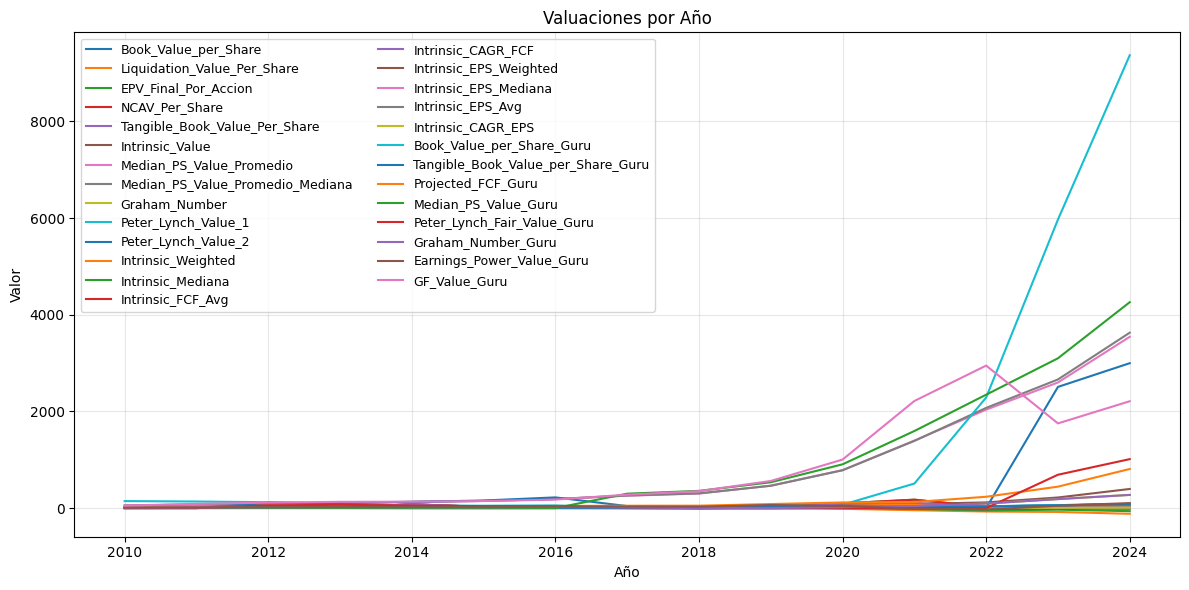

In [155]:

df_plot = df_valuaciones.sort_values("Año")

plt.figure(figsize=(12, 6))

for col in df_plot.columns[1:]:
    plt.plot(df_plot["Año"], df_plot[col], label=col)

plt.xlabel("Año")
plt.ylabel("Valor")
plt.title("Valuaciones por Año")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## Modelo de Targets

In [156]:
data_stock_modelo = pd.read_csv(archivo_stock + '.csv')
data_stock_modelo.drop(columns=["Vol.","Cierre","Apertura"],axis=1, inplace=True)
data_stock_modelo["Fecha"] = pd.to_datetime(
    data_stock_modelo["Fecha"],
    format="%Y-%m-%d"
)

In [157]:
prices = data_stock_modelo.copy()

prices["Fecha"] = pd.to_datetime(prices["Fecha"])

prices = prices.sort_values("Fecha").reset_index(drop=True)

prices.head()

,Fecha,Máximo,Mínimo
0,2007-08-06,28.100933,20.348951
1,2007-08-13,38.440135,24.283081
2,2007-08-20,32.461427,26.899380
3,2007-08-27,29.767607,27.131934
4,2007-09-03,31.250178,26.162940


In [158]:
mes_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

headers_df = pd.DataFrame({
    "Header": valid_headers
})

headers_df["Mes"] = headers_df["Header"].str[:3].map(mes_map)
headers_df["Año"] = headers_df["Header"].str[-4:].astype(int)

# Fecha base = primer día del mes del header
headers_df["Fecha_base"] = pd.to_datetime(
    headers_df["Año"].astype(str) + "-" +
    headers_df["Mes"].astype(str).str.zfill(2) + "-01"
)

headers_df["Fecha_teorica"] = headers_df["Fecha_base"] + pd.DateOffset(months=1)

valuations = df_valuaciones.copy()

valuations = valuations.merge(
    headers_df[["Año", "Fecha_teorica"]],
    on="Año",
    how="left"
)

In [159]:
price_dates = prices[["Fecha"]]

valuations = pd.merge_asof(
    valuations.sort_values("Fecha_teorica"),
    price_dates.sort_values("Fecha"),
    left_on="Fecha_teorica",
    right_on="Fecha",
    direction="forward"
)

valuations = valuations.rename(columns={"Fecha": "Fecha_base"})

valuations[["Año", "Fecha_teorica", "Fecha_base"]].head()


,Año,Fecha_teorica,Fecha_base
0,2010,2011-01-01,2011-01-03
1,2011,2012-01-01,2012-01-02
2,2012,2013-01-01,2013-01-07
3,2013,2014-01-01,2014-01-06
4,2014,2015-01-01,2015-01-05


In [160]:
id_cols = ["Año", "Fecha_base"]

# Asegúrate de no tener columnas duplicadas
valuations = valuations.loc[:, ~valuations.columns.duplicated()].copy()

# Seleccionar SOLO columnas de métodos (numéricas) y excluir id_cols
method_cols = [
    c for c in valuations.columns
    if c not in id_cols and pd.api.types.is_numeric_dtype(valuations[c])
]

valuations_long = valuations.melt(
    id_vars=id_cols,
    value_vars=method_cols,
    var_name="Metodo",
    value_name="Valor"
)

# Forzar a numérico y limpiar
valuations_long["Valor"] = pd.to_numeric(valuations_long["Valor"], errors="coerce")
valuations_long = valuations_long.dropna(subset=["Valor"])


In [161]:
valuations_long

,Año,Fecha_base,Metodo,Valor
0,2010,2011-01-03,Book_Value_per_Share,3.891714
1,2011,2012-01-02,Book_Value_per_Share,4.965766
2,2012,2013-01-07,Book_Value_per_Share,6.564578
3,2013,2014-01-06,Book_Value_per_Share,7.779403
4,2014,2015-01-05,Book_Value_per_Share,8.057888
...,...,...,...,...
400,2020,2021-01-04,GF_Value_Guru,1003.920000
401,2021,2022-01-03,GF_Value_Guru,2215.640000
402,2022,2023-01-02,GF_Value_Guru,2947.550000
403,2023,2024-01-01,GF_Value_Guru,1752.140000


In [162]:
tol = 0.05
H = 156

prices["Fecha"] = pd.to_datetime(prices["Fecha"])
prices = prices.sort_values("Fecha").reset_index(drop=True)

# Ajusta estos nombres 
HIGH_COL = "Máximo"
LOW_COL  = "Mínimo"

# Chequeos rápidos
assert prices["Fecha"].is_monotonic_increasing
assert {HIGH_COL, LOW_COL}.issubset(prices.columns)
assert {"Fecha_base", "Metodo", "Valor"}.issubset(valuations_long.columns)

In [163]:
valuations_long["L"] = valuations_long["Valor"] * (1 - tol)
valuations_long["U"] = valuations_long["Valor"] * (1 + tol)


In [164]:
valuations_long["Fecha_fin"] = valuations_long["Fecha_base"] + pd.to_timedelta(H, unit="W")

In [165]:
prices["Fecha"] = pd.to_datetime(prices["Fecha"], errors="coerce")

# Limpieza: quitar comas de miles y convertir a float
for c in [HIGH_COL, LOW_COL]: 
    prices[c] = (
        prices[c]
        .astype(str)
        .str.replace(",", "", regex=False) 
        .str.replace(" ", "", regex=False)
    )
    prices[c] = pd.to_numeric(prices[c], errors="coerce")


prices = prices.dropna(subset=["Fecha", HIGH_COL, LOW_COL]).sort_values("Fecha").reset_index(drop=True)

In [166]:
def first_hit(fecha_base, fecha_fin, valor, L, U):
    if valor is None or pd.isna(valor) or valor <= 0:
        return np.nan, np.nan, pd.NaT, pd.NA

    w = prices.loc[
        (prices["Fecha"] >= fecha_base) & (prices["Fecha"] <= fecha_fin),
        ["Fecha", HIGH_COL, LOW_COL]
    ]

    if w.empty:
        return False, np.nan, pd.NaT, pd.NA

    hit_mask = (w[LOW_COL] <= U) & (w[HIGH_COL] >= L)
    if not hit_mask.any():
        # side basado en p_base aunque no haya hit
        base_high = w.iloc[0][HIGH_COL]
        base_low  = w.iloc[0][LOW_COL]
        p_base = (base_high + base_low) / 2
        if p_base < L:
            side = "long"
        elif p_base > U:
            side = "short"
        else:
            side = "at_target"
        return False, np.nan, pd.NaT, side

    first_pos = int(np.argmax(hit_mask.to_numpy()))
    hit_date = w.iloc[first_pos]["Fecha"]
    tth_weeks = first_pos

    if first_pos == 0:
        side = "at_target"
    else:
        base_high = w.iloc[0][HIGH_COL]
        base_low  = w.iloc[0][LOW_COL]
        p_base = (base_high + base_low) / 2
        if p_base < L:
            side = "long"
        elif p_base > U:
            side = "short"
        else:
            side = "at_target"

    return True, tth_weeks, hit_date, side


In [167]:
hits = valuations_long.apply(
    lambda r: first_hit(r["Fecha_base"], r["Fecha_fin"], r["Valor"], r["L"], r["U"]),
    axis=1,
    result_type="expand"
)

hits.columns = ["hit", "tth_weeks", "hit_date", "side"]
valuations_long[["hit", "tth_weeks", "hit_date", "side"]] = hits


In [168]:
valuations_long.to_excel('valuaciones_long_format.xlsx', index=False)

In [169]:
valuations_long[["Año","Metodo","Valor","Fecha_base","hit","tth_weeks","hit_date"]]

# Convertir NaT -> NaN en hit (y cualquier cosa rara)
valuations_long["hit"] = valuations_long["hit"].replace({pd.NaT: np.nan})

# Fuerza dtype booleano nullable (permite True/False/<NA>)
valuations_long["hit"] = valuations_long["hit"].astype("boolean")


In [170]:
summary = (
    valuations_long
    .groupby("Metodo", as_index=False)
    .agg(
        targets=("hit", "count"),       
        hits=("hit", "sum"),              
        hit_rate=("hit", "mean"),        
        median_tth=("tth_weeks", "median"),
        avg_tth=("tth_weeks", "mean"),
    )
)

for years, weeks in [(1, 52), (2, 104), (3, 156)]:
    col = f"hit_le_{years}y"

    tmp = valuations_long["hit"] & (valuations_long["tth_weeks"] <= weeks)

    summary[col] = (
        valuations_long
        .assign(_tmp=tmp)
        .groupby("Metodo")["_tmp"]
        .mean()            
        .values
    )

summary = summary.sort_values(
    ["hit_rate", "median_tth"],
    ascending=[False, True]
).reset_index(drop=True)


In [171]:
metodos_top = summary.loc[summary["hit_rate"] >= 0.60, "Metodo"]

df_hits_por_anio = (
    valuations_long
    .loc[
        valuations_long["Metodo"].isin(metodos_top),
        ["Año", "Metodo", "Valor", "hit", "tth_weeks", "hit_date","side"]
    ]
    .sort_values(["Metodo", "Año"])
    .reset_index(drop=True)
)

df_hits_por_anio

,Año,Metodo,Valor,hit,tth_weeks,hit_date,side
0,2010,GF_Value_Guru,52.940000,True,38.0,2011-09-26,short
1,2011,GF_Value_Guru,86.220000,True,1.0,2012-01-09,long
2,2012,GF_Value_Guru,113.080000,True,17.0,2013-05-06,long
3,2013,GF_Value_Guru,129.680000,True,42.0,2014-10-27,long
4,2014,GF_Value_Guru,132.480000,True,2.0,2015-01-19,long
...,...,...,...,...,...,...,...
70,2020,Peter_Lynch_Value_2,0.000000,<NA>,NaN,NaT,<NA>
71,2021,Peter_Lynch_Value_2,0.000000,<NA>,NaN,NaT,<NA>
72,2022,Peter_Lynch_Value_2,0.000000,<NA>,NaN,NaT,<NA>
73,2023,Peter_Lynch_Value_2,2506.686336,True,70.0,2025-05-05,long


In [172]:
df_hits_por_anio.to_excel(f'Valuaciones_USA/valuaciones_hits_por_anio_{ticket}.xlsx', index=False)